# MOEX Si thesis workflow — multi-scale CNN + ablations + selective tails + Grad-CAM + benchmarks

This Colab notebook is built for the thesis:

**Intraday Decision Support for Traders: Explainable CNN-Based Directional Price Forecasting from Candlestick Chart Images**

It is designed to cover the five main points discussed in the supervisor meeting:

1. **Multi-scale intraday input**
2. **Image-component ablations**
3. **Selective tail-rule decision support**
4. **Grad-CAM chart-vs-background analysis**
5. **Simple benchmark comparisons**

## What this notebook does
- reads the **14 raw 1-minute MOEX Si contract candle CSVs** uploaded in Colab (left sidebar) or stored in Drive
- optionally reads the **FUTOI** file
- resamples to **15-minute OHLCV**
- selects the **front contract** by realized daily volume
- builds a clean continuous-front branch
- creates chronology-safe **master samples**
- trains:
  - **simple benchmark models**
  - **single-scale CNNs**
  - **image ablations**
  - **multi-scale CNN fusion**
- evaluates:
  - **full-sample metrics**
  - **tail-rule metrics**
  - **Grad-CAM chart-focused vs background-focused cases**

## Important honesty note
This notebook is built to be **end-to-end workable** and to hit the requested research points.
No notebook can honestly guarantee the **best possible score** in advance.
It gives you a strong, reproducible framework to search for the best result on your data.

In [ ]:

# Colab / Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# ===== USER CONFIG =====
from pathlib import Path

# Change only if needed
PROJECT_ROOT = Path('/content/drive/MyDrive/moex_si_thesis_v2')
RAW_DIR = Path('/content')                      # uploaded files from left sidebar usually appear here
WORK_DIR = PROJECT_ROOT / 'work'
DERIVED_DIR = PROJECT_ROOT / 'derived'
RESULT_DIR = PROJECT_ROOT / 'results'
MODEL_DIR = PROJECT_ROOT / 'models'
FIG_DIR = PROJECT_ROOT / 'figures'
CACHE_DIR = PROJECT_ROOT / 'cache'

for p in [WORK_DIR, DERIVED_DIR, RESULT_DIR, MODEL_DIR, FIG_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# File patterns
SI_PATTERN = 'Si*_candles_2024-01-01_2025-12-31_1m.csv'
FUTOI_PATTERN = 'Si_futoi_2024-01-01_2025-12-31.csv'

# Thesis / experiment settings
BAR_FREQ = '15min'
HORIZON = 20
SCALES = [20, 60]           # multi-scale input; add 120 later if you want a heavier run
MAX_LOOKBACK = max(SCALES)

# Intraday target rule
REQUIRE_FUTURE_SAME_DAY = True          # future target remains intraday
ALLOW_INPUT_CROSS_DAY = True            # needed for long contexts like I60

# q-filter
USE_Q_FILTER = True
Q_FILTER = 0.10                         # remove smallest 10% absolute train returns

# Front selection / cleaning
MIN_DAILY_VOLUME = 100_000
EXCLUDE_ROLL_DAY = True

# Image settings
BAR_PIXELS = 3
HEIGHT_MAP = {20: 64, 60: 96, 120: 128}
PRICE_PANEL_RATIO = 0.80
VERTICAL_PADDING_FRAC = 0.03

# Training
SEED = 42
BATCH_SIZE = 64
MAX_EPOCHS = 20
PATIENCE = 5
NUM_WORKERS = 2
DEVICE_PREFERRED = 'cuda'

# Model search knobs
LR_SINGLE = 1e-4
LR_MULTI = 1e-4
WEIGHT_DECAY = 1e-4
THRESHOLD_METRIC = 'balanced_accuracy'   # threshold chosen on validation only
TAIL_GRID = [0.01, 0.015, 0.025, 0.05, 0.10]   # two-sided tails

In [ ]:

# Imports
import os, gc, math, json, random, shutil, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    matthews_corrcoef, precision_score, recall_score, confusion_matrix,
    log_loss, brier_score_loss
)
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

In [ ]:

# Reproducibility and device
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device('cuda' if (DEVICE_PREFERRED == 'cuda' and torch.cuda.is_available()) else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 1) Discover and optionally copy the uploaded raw files
Upload the **14 contract CSVs** and the **FUTOI** file in the left Colab sidebar first.
Then run the next cells.

In [ ]:

# Discover raw files
si_files = sorted(RAW_DIR.glob(SI_PATTERN))
futoi_files = sorted(RAW_DIR.glob(FUTOI_PATTERN))

print('Found SI files:', len(si_files))
for f in si_files[:5]:
    print('  ', f.name)
print('Found FUTOI files:', len(futoi_files), [f.name for f in futoi_files])

assert len(si_files) >= 8, 'Upload the raw SI candle files first.'

Found SI files: 14
   SiH4_candles_2024-01-01_2025-12-31_1m.csv
   SiH5_candles_2024-01-01_2025-12-31_1m.csv
   SiH6_candles_2024-01-01_2025-12-31_1m.csv
   SiH7_candles_2024-01-01_2025-12-31_1m.csv
   SiM4_candles_2024-01-01_2025-12-31_1m.csv
Found FUTOI files: 1 ['Si_futoi_2024-01-01_2025-12-31.csv']


In [ ]:

# Optional backup to Drive
BACKUP_RAW_TO_DRIVE = False

if BACKUP_RAW_TO_DRIVE:
    raw_backup = PROJECT_ROOT / 'raw_backup'
    raw_backup.mkdir(parents=True, exist_ok=True)
    for fp in si_files + futoi_files:
        dst = raw_backup / fp.name
        if not dst.exists():
            shutil.copy2(fp, dst)
    print('Raw files copied to', raw_backup)
else:
    print('Skipping raw backup copy.')

Skipping raw backup copy.


## 2) Load and standardize the raw candle files
This section merges the raw 1-minute contract files into one long table and then resamples to 15-minute bars.

In [ ]:

def standardize_candle_csv(fp: Path) -> pd.DataFrame:
    df = pd.read_csv(fp)
    cols = {c.lower(): c for c in df.columns}

    # Required columns in your MOEX files are expected to be present under these names or close variants
    rename_map = {}
    for want in ['begin', 'open', 'high', 'low', 'close', 'volume', 'value', 'secid']:
        for c in df.columns:
            if c.lower() == want:
                rename_map[c] = want
                break
    df = df.rename(columns=rename_map)

    required = ['begin', 'open', 'high', 'low', 'close', 'volume']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f'{fp.name}: missing columns {missing}')

    if 'secid' not in df.columns:
        # infer from file name
        secid = fp.name.split('_candles_')[0]
        df['secid'] = secid

    if 'value' not in df.columns:
        df['value'] = 0.0

    df['begin'] = pd.to_datetime(df['begin'])
    df = df.sort_values('begin').reset_index(drop=True)

    keep = ['begin', 'open', 'high', 'low', 'close', 'volume', 'value', 'secid']
    return df[keep].copy()

raw_fp = DERIVED_DIR / 'si_1m_merged_raw.parquet'
if raw_fp.exists():
    raw_1m = pd.read_parquet(raw_fp)
else:
    parts = []
    for fp in tqdm(si_files, desc='Loading raw candle files'):
        x = standardize_candle_csv(fp)
        x['contract'] = x['secid']
        parts.append(x)
    raw_1m = pd.concat(parts, ignore_index=True)
    raw_1m['trade_date'] = raw_1m['begin'].dt.date
    raw_1m.to_parquet(raw_fp, index=False)

raw_1m.head(), raw_1m.shape

Loading raw candle files:   0%|          | 0/14 [00:00<?, ?it/s]

(                begin   open   high    low  close  volume  value secid  \
 0 2024-01-03 08:59:00  92000  92000  91965  92000    1982      0  SiH4   
 1 2024-01-03 09:00:00  92002  92100  92002  92073    4407      0  SiH4   
 2 2024-01-03 09:01:00  92072  92088  92032  92084    1409      0  SiH4   
 3 2024-01-03 09:02:00  92079  92097  92076  92096     560      0  SiH4   
 4 2024-01-03 09:03:00  92095  92110  92085  92095     946      0  SiH4   
 
   contract  trade_date  
 0     SiH4  2024-01-03  
 1     SiH4  2024-01-03  
 2     SiH4  2024-01-03  
 3     SiH4  2024-01-03  
 4     SiH4  2024-01-03  ,
 (775621, 10))

In [ ]:

def resample_contract_to_15m(df_contract: pd.DataFrame, freq='15min') -> pd.DataFrame:
    x = df_contract.sort_values('begin').copy()
    x = x.set_index('begin')

    out = x.resample(freq, label='left', closed='left').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum',
        'value': 'sum',
        'secid': 'last',
        'contract': 'last',
    }).dropna(subset=['open', 'high', 'low', 'close']).reset_index()

    out['trade_date'] = out['begin'].dt.date
    return out

resampled_fp = DERIVED_DIR / 'si_candles_15m_by_contract.parquet'
if resampled_fp.exists():
    si_15m = pd.read_parquet(resampled_fp)
else:
    chunks = []
    for secid, g in tqdm(raw_1m.groupby('contract'), desc='Resampling by contract'):
        chunks.append(resample_contract_to_15m(g, BAR_FREQ))
    si_15m = pd.concat(chunks, ignore_index=True)
    si_15m.to_parquet(resampled_fp, index=False)

si_15m.head(), si_15m.shape

Resampling by contract:   0%|          | 0/14 [00:00<?, ?it/s]

(                begin     open     high      low    close  volume  value  \
 0 2024-01-03 08:45:00  92000.0  92000.0  91965.0  92000.0    1982      0   
 1 2024-01-03 09:00:00  92002.0  92185.0  92002.0  92181.0   14431      0   
 2 2024-01-03 09:15:00  92183.0  92218.0  92123.0  92173.0    5678      0   
 3 2024-01-03 09:30:00  92172.0  92207.0  92155.0  92156.0    2936      0   
 4 2024-01-03 09:45:00  92156.0  92170.0  92142.0  92170.0    1884      0   
 
   secid contract  trade_date  
 0  SiH4     SiH4  2024-01-03  
 1  SiH4     SiH4  2024-01-03  
 2  SiH4     SiH4  2024-01-03  
 3  SiH4     SiH4  2024-01-03  
 4  SiH4     SiH4  2024-01-03  ,
 (89628, 10))

## 3) Front-contract selection and clean continuous-front branch
The front contract is chosen by **highest realized daily volume**.
Then a liquidity filter removes weak days.

In [ ]:

# Daily realized volume per contract
front_daily_fp = DERIVED_DIR / 'si_front_daily_contracts_clean.parquet'
cf_fp = DERIVED_DIR / 'si_continuous_front_15m_clean_v2.parquet'

if front_daily_fp.exists() and cf_fp.exists():
    front_daily = pd.read_parquet(front_daily_fp)
    cf = pd.read_parquet(cf_fp)
else:
    daily_vol = (
        si_15m.groupby(['trade_date', 'contract'], as_index=False)
             .agg(daily_volume=('volume', 'sum'))
    )

    # Pick front by max daily volume
    front_daily = (
        daily_vol.sort_values(['trade_date', 'daily_volume', 'contract'], ascending=[True, False, True])
                 .drop_duplicates('trade_date')
                 .rename(columns={'contract': 'front_contract'})
    )

    # Liquidity filter
    front_daily = front_daily[front_daily['daily_volume'] >= MIN_DAILY_VOLUME].copy()
    front_daily = front_daily.sort_values('trade_date').reset_index(drop=True)
    front_daily['prev_front'] = front_daily['front_contract'].shift(1)
    front_daily['is_roll_day'] = front_daily['front_contract'] != front_daily['prev_front']
    front_daily.loc[front_daily.index[0], 'is_roll_day'] = True

    # Join back
    cf = si_15m.merge(front_daily[['trade_date', 'front_contract', 'is_roll_day']], on='trade_date', how='inner')
    cf = cf[cf['contract'] == cf['front_contract']].copy()
    cf = cf.sort_values('begin').reset_index(drop=True)

    front_daily.to_parquet(front_daily_fp, index=False)
    cf.to_parquet(cf_fp, index=False)

front_daily.head(), cf.shape

(   trade_date front_contract  daily_volume prev_front  is_roll_day
 0  2024-01-03           SiH4        438437       None         True
 1  2024-01-04           SiH4        508126       SiH4        False
 2  2024-01-05           SiH4        489735       SiH4        False
 3  2024-01-08           SiH4        726473       SiH4        False
 4  2024-01-09           SiH4        943599       SiH4        False,
 (29926, 12))

In [ ]:

# Quick diagnostics
print('Front contracts used:', sorted(cf['contract'].unique()))
print('Trade dates:', cf['trade_date'].min(), 'to', cf['trade_date'].max(), '| n =', cf['trade_date'].nunique())
print('Rows:', len(cf))
print('Rows by contract:')
display(cf['contract'].value_counts().sort_index().to_frame('rows'))

Front contracts used: ['SiH4', 'SiH5', 'SiM4', 'SiM5', 'SiU4', 'SiU5', 'SiZ4', 'SiZ5']
Trade dates: 2024-01-03 to 2025-12-18 | n = 502
Rows: 29926
Rows by contract:


,rows
contract,
SiH4,3294
SiH5,3686
SiM4,3823
SiM5,3776
SiU4,3685
SiU5,3898
SiZ4,3702
SiZ5,4062


## 4) Build a master sample index
We build one **master manifest** using the largest lookback.
Any smaller scale is later derived from the same anchor timestamp, so all scales stay aligned for fusion.

In [ ]:

def build_master_manifest(
    cf: pd.DataFrame,
    max_lookback: int,
    horizon: int,
    require_future_same_day: bool = True,
    allow_input_cross_day: bool = True,
    exclude_roll_day: bool = True,
):
    x = cf.copy().reset_index(drop=True)
    rows = []
    n = len(x)

    for anchor_idx in tqdm(range(max_lookback - 1, n - horizon), desc='Building master manifest'):
        anchor = x.iloc[anchor_idx]
        future = x.iloc[anchor_idx + horizon]

        start_idx = anchor_idx - max_lookback + 1
        end_idx = anchor_idx + horizon

        block = x.iloc[start_idx:end_idx + 1]

        # Full path must stay in one contract
        if block['contract'].nunique() != 1:
            continue

        # Optionally keep intraday target
        if require_future_same_day and future['trade_date'] != anchor['trade_date']:
            continue

        # Optionally force input to stay same day too
        if not allow_input_cross_day:
            if x.iloc[start_idx:anchor_idx + 1]['trade_date'].nunique() != 1:
                continue

        # Avoid roll contamination
        if exclude_roll_day and block['is_roll_day'].any():
            continue

        ret = (future['close'] / anchor['close']) - 1.0
        rows.append({
            'sample_id': len(rows),
            'anchor_idx': int(anchor_idx),
            'future_idx': int(anchor_idx + horizon),
            'anchor_ts': anchor['begin'],
            'future_ts': future['begin'],
            'trade_date': anchor['trade_date'],
            'future_trade_date': future['trade_date'],
            'contract': anchor['contract'],
            'forward_return': float(ret),
            'label_up': int(ret > 0),
        })

    return pd.DataFrame(rows)

master_fp = DERIVED_DIR / f'master_manifest_I{MAX_LOOKBACK}_R{HORIZON}.parquet'
if master_fp.exists():
    master = pd.read_parquet(master_fp)
else:
    master = build_master_manifest(
        cf=cf,
        max_lookback=MAX_LOOKBACK,
        horizon=HORIZON,
        require_future_same_day=REQUIRE_FUTURE_SAME_DAY,
        allow_input_cross_day=ALLOW_INPUT_CROSS_DAY,
        exclude_roll_day=EXCLUDE_ROLL_DAY,
    )
    master.to_parquet(master_fp, index=False)

master.head(), master.shape

Building master manifest:   0%|          | 0/29847 [00:00<?, ?it/s]

(   sample_id  anchor_idx  future_idx           anchor_ts           future_ts  \
 0          0         122         142 2024-01-05 08:45:00 2024-01-05 13:45:00   
 1          1         123         143 2024-01-05 09:00:00 2024-01-05 14:00:00   
 2          2         124         144 2024-01-05 09:15:00 2024-01-05 14:15:00   
 3          3         125         145 2024-01-05 09:30:00 2024-01-05 14:30:00   
 4          4         126         146 2024-01-05 09:45:00 2024-01-05 14:45:00   
 
    trade_date future_trade_date contract  forward_return  label_up  
 0  2024-01-05        2024-01-05     SiH4       -0.006706         0  
 1  2024-01-05        2024-01-05     SiH4       -0.008950         0  
 2  2024-01-05        2024-01-05     SiH4       -0.007553         0  
 3  2024-01-05        2024-01-05     SiH4       -0.009006         0  
 4  2024-01-05        2024-01-05     SiH4       -0.009470         0  ,
 (19249, 10))

In [ ]:

# Strict chronological split by unique trade date
dates = sorted(pd.Series(master['trade_date']).unique())
n_dates = len(dates)
train_end = int(0.70 * n_dates)
val_end = int(0.85 * n_dates)

train_dates = set(dates[:train_end])
val_dates = set(dates[train_end:val_end])
test_dates = set(dates[val_end:])

def assign_split(d):
    if d in train_dates:
        return 'train'
    if d in val_dates:
        return 'val'
    return 'test'

master['split'] = master['trade_date'].map(assign_split)

# q-filter based on training only
if USE_Q_FILTER:
    q_thr = master.loc[master['split'] == 'train', 'forward_return'].abs().quantile(Q_FILTER)
    master['keep_q'] = master['forward_return'].abs() > q_thr
else:
    q_thr = 0.0
    master['keep_q'] = True

master_q = master[master['keep_q']].copy().reset_index(drop=True)
print('Q-filter threshold:', q_thr)
print(master_q['split'].value_counts())
display(master_q.groupby('split')['label_up'].mean().to_frame('positive_rate'))

Q-filter threshold: 0.00038779644882541714
split
train    11964
test      2722
val       2617
Name: count, dtype: int64


,positive_rate
split,
test,0.421014
train,0.481862
val,0.436760


## 5) Render reference-style grayscale chart images
We render **OHLC bars**, optional **moving average**, and optional **volume panel**.
This lets us test the image-component ablations cleanly.

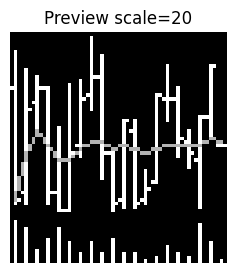

In [ ]:

def get_shape_for_scale(scale: int):
    h = HEIGHT_MAP.get(scale, 96)
    w = BAR_PIXELS * scale
    return h, w

def render_refstyle_window(
    window_df: pd.DataFrame,
    scale: int,
    include_ma: bool = True,
    include_volume: bool = True,
    bg_color=0,
    fg_color=255,
):
    H, W = get_shape_for_scale(scale)
    price_h = int(round(H * PRICE_PANEL_RATIO))
    vol_h = H - price_h

    img = Image.new('L', (W, H), color=bg_color)
    draw = ImageDraw.Draw(img)

    wdf = window_df.tail(scale).copy().reset_index(drop=True)

    # Price scaling
    px_min = wdf['low'].min()
    px_max = wdf['high'].max()
    px_rng = max(float(px_max - px_min), 1e-9)
    pad = px_rng * VERTICAL_PADDING_FRAC
    px_low = px_min - pad
    px_high = px_max + pad
    px_den = max(px_high - px_low, 1e-9)

    def y_price(v):
        # invert y
        return int(round((price_h - 1) - (float(v) - px_low) / px_den * (price_h - 1)))

    # Volume scaling
    vmax = max(float(wdf['volume'].max()), 1.0)

    # Draw OHLC bars
    for i, row in wdf.iterrows():
        x0 = i * BAR_PIXELS
        xc = x0 + 1
        xl = x0
        xr = x0 + 2

        yh = y_price(row['high'])
        yl = y_price(row['low'])
        yo = y_price(row['open'])
        yc = y_price(row['close'])

        draw.line([(xc, yh), (xc, yl)], fill=fg_color, width=1)
        draw.point((xl, yo), fill=fg_color)
        draw.point((xr, yc), fill=fg_color)

        if include_volume and vol_h > 0:
            vh = int(round((float(row['volume']) / vmax) * max(vol_h - 1, 1)))
            v_top = H - vh
            draw.line([(xc, H - 1), (xc, v_top)], fill=fg_color, width=1)

    # Draw moving average over close
    if include_ma:
        ma = wdf['close'].rolling(scale, min_periods=1).mean()
        pts = []
        for i, v in enumerate(ma):
            x = i * BAR_PIXELS + 1
            y = y_price(v)
            pts.append((x, y))
        if len(pts) >= 2:
            draw.line(pts, fill=180, width=1)  # gray line

    return img

# Example preview
ex = master_q.iloc[0]
anchor_idx = int(ex['anchor_idx'])
scale = SCALES[0]
window = cf.iloc[anchor_idx - scale + 1: anchor_idx + 1].copy()
preview = render_refstyle_window(window, scale=scale, include_ma=True, include_volume=True)
plt.figure(figsize=(8, 3))
plt.imshow(preview, cmap='gray')
plt.axis('off')
plt.title(f'Preview scale={scale}')
plt.show()

In [ ]:

# Optional image cache for speed
def get_cache_subdir(scale, include_ma, include_volume):
    tag = f'I{scale}_ma{int(include_ma)}_vol{int(include_volume)}'
    out = CACHE_DIR / tag
    out.mkdir(parents=True, exist_ok=True)
    return out

def pre_render_cache(master_df, scales, ablation_grid):
    for scale in scales:
        for include_ma, include_volume in ablation_grid:
            out_dir = get_cache_subdir(scale, include_ma, include_volume)
            for _, r in tqdm(master_df.iterrows(), total=len(master_df), desc=f'Caching I{scale} ma={include_ma} vol={include_volume}'):
                fp = out_dir / f"{int(r['sample_id'])}.png"
                if fp.exists():
                    continue
                a = int(r['anchor_idx'])
                window = cf.iloc[a - scale + 1: a + 1].copy()
                img = render_refstyle_window(window, scale=scale, include_ma=include_ma, include_volume=include_volume)
                img.save(fp)

ABLATION_GRID = [(False, False), (True, False), (False, True), (True, True)]
PRE_RENDER_IMAGES = False   # set True for faster repeated runs at the cost of time/storage

if PRE_RENDER_IMAGES:
    pre_render_cache(master_q, SCALES, ABLATION_GRID)
else:
    print('Skipping pre-render cache.')

Skipping pre-render cache.


## 6) Datasets and models
We define:
- a **single-scale CNN**
- a **multi-scale fusion CNN**
- a **simple numeric benchmark feature set**

In [ ]:

# Torch transforms
to_tensor = transforms.Compose([
    transforms.ToTensor(),   # [0,1], shape [1,H,W]
])

class SingleScaleChartDataset(Dataset):
    def __init__(self, manifest_df, cf_df, scale, include_ma=True, include_volume=True, use_cache=False):
        self.df = manifest_df.reset_index(drop=True)
        self.cf = cf_df
        self.scale = scale
        self.include_ma = include_ma
        self.include_volume = include_volume
        self.use_cache = use_cache
        self.cache_dir = get_cache_subdir(scale, include_ma, include_volume)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        sid = int(r['sample_id'])
        if self.use_cache and (self.cache_dir / f'{sid}.png').exists():
            img = Image.open(self.cache_dir / f'{sid}.png').convert('L')
        else:
            a = int(r['anchor_idx'])
            window = self.cf.iloc[a - self.scale + 1: a + 1].copy()
            img = render_refstyle_window(window, self.scale, self.include_ma, self.include_volume)
        x = to_tensor(img)
        y = int(r['label_up'])
        return {
            'x': x,
            'y': y,
            'sample_id': sid,
            'anchor_ts': r['anchor_ts'],
            'contract': r['contract'],
            'forward_return': float(r['forward_return']),
        }

class MultiScaleChartDataset(Dataset):
    def __init__(self, manifest_df, cf_df, scales, include_ma=True, include_volume=True, use_cache=False):
        self.df = manifest_df.reset_index(drop=True)
        self.cf = cf_df
        self.scales = list(scales)
        self.include_ma = include_ma
        self.include_volume = include_volume
        self.use_cache = use_cache
        self.cache_dirs = {s: get_cache_subdir(s, include_ma, include_volume) for s in scales}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        sid = int(r['sample_id'])
        out = {}
        for s in self.scales:
            fp = self.cache_dirs[s] / f'{sid}.png'
            if self.use_cache and fp.exists():
                img = Image.open(fp).convert('L')
            else:
                a = int(r['anchor_idx'])
                window = self.cf.iloc[a - s + 1: a + 1].copy()
                img = render_refstyle_window(window, s, self.include_ma, self.include_volume)
            out[f'x_{s}'] = to_tensor(img)
        out['y'] = int(r['label_up'])
        out['sample_id'] = sid
        out['anchor_ts'] = r['anchor_ts']
        out['contract'] = r['contract']
        out['forward_return'] = float(r['forward_return'])
        return out

In [ ]:

class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=1, base=32, depth=4):
        super().__init__()
        channels = []
        c = base
        for i in range(depth):
            channels.append(c)
            c = min(c * 2, 256)

        blocks = []
        prev = in_channels
        for c in channels:
            blocks.extend([
                nn.Conv2d(prev, c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c),
                nn.LeakyReLU(0.01, inplace=True),
                nn.MaxPool2d(2, 2),
            ])
            prev = c
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.out_dim = prev * 4 * 4

    def forward(self, x):
        z = self.backbone(x)
        z = self.pool(z)
        z = torch.flatten(z, 1)
        return z

def depth_for_scale(scale):
    if scale <= 20:
        return 3
    elif scale <= 60:
        return 4
    else:
        return 5

class RefStyleCNN(nn.Module):
    def __init__(self, scale, dropout=0.5):
        super().__init__()
        self.scale = scale
        self.fe = CNNFeatureExtractor(depth=depth_for_scale(scale))
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.fe.out_dim, 2),
        )
    def forward(self, x):
        z = self.fe(x)
        return self.head(z)

class MultiScaleFusionCNN(nn.Module):
    def __init__(self, scales, dropout=0.5):
        super().__init__()
        self.scales = list(scales)
        self.branches = nn.ModuleDict({
            str(s): CNNFeatureExtractor(depth=depth_for_scale(s)) for s in scales
        })
        total_dim = sum(self.branches[str(s)].out_dim for s in scales)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(total_dim, 128),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, batch_x_dict):
        feats = []
        for s in self.scales:
            feats.append(self.branches[str(s)](batch_x_dict[f'x_{s}']))
        z = torch.cat(feats, dim=1)
        return self.head(z)

In [ ]:

# Numeric benchmark features
def build_numeric_features(master_df, cf_df):
    rows = []
    for _, r in tqdm(master_df.iterrows(), total=len(master_df), desc='Building numeric features'):
        a = int(r['anchor_idx'])
        x20 = cf_df.iloc[a - 20 + 1: a + 1].copy()
        x60 = cf_df.iloc[a - 60 + 1: a + 1].copy()

        close20 = x20['close'].values
        close60 = x60['close'].values

        def safe_ret(arr):
            return float(arr[-1] / arr[0] - 1.0) if len(arr) > 1 and arr[0] != 0 else 0.0

        feat = {
            'sample_id': int(r['sample_id']),
            'label_up': int(r['label_up']),
            'split': r['split'],
            'forward_return': float(r['forward_return']),
            'contract': r['contract'],
            'mom_5h': safe_ret(close20),
            'mom_15h': safe_ret(close60),
            'range_20': float((x20['high'].max() - x20['low'].min()) / max(abs(x20['close'].iloc[-1]), 1e-9)),
            'close_vs_ma20': float((x20['close'].iloc[-1] / max(x20['close'].rolling(20, min_periods=1).mean().iloc[-1], 1e-9)) - 1.0),
            'vol_ratio_20': float(x20['volume'].iloc[-1] / max(x20['volume'].rolling(20, min_periods=1).mean().iloc[-1], 1.0)),
            'last_bar_body': float((x20['close'].iloc[-1] - x20['open'].iloc[-1]) / max(abs(x20['open'].iloc[-1]), 1e-9)),
            'last_bar_range': float((x20['high'].iloc[-1] - x20['low'].iloc[-1]) / max(abs(x20['close'].iloc[-1]), 1e-9)),
        }
        rows.append(feat)
    return pd.DataFrame(rows)

bench_fp = DERIVED_DIR / 'numeric_bench_features.parquet'
if bench_fp.exists():
    bench_df = pd.read_parquet(bench_fp)
else:
    bench_df = build_numeric_features(master_q, cf)
    bench_df.to_parquet(bench_fp, index=False)

bench_df.head()

Building numeric features:   0%|          | 0/17303 [00:00<?, ?it/s]

,sample_id,label_up,split,forward_return,contract,mom_5h,mom_15h,range_20,close_vs_ma20,vol_ratio_20,last_bar_body,last_bar_range
0,0,0,train,-0.006706,SiH4,0.000282,-0.009746,0.000911,-0.000031,0.039925,0.000000,0.000000
1,1,0,train,-0.008950,SiH4,0.001172,-0.006983,0.001820,0.001264,5.865431,0.001204,0.001582
2,2,0,train,-0.007553,SiH4,0.001063,-0.006973,0.001820,0.001195,2.196381,0.000011,0.000769
3,3,0,train,-0.009006,SiH4,0.002670,-0.003065,0.002901,0.002152,5.161634,0.001062,0.001201
4,4,0,train,-0.009470,SiH4,0.002898,-0.003645,0.003431,0.002142,3.486272,0.000130,0.000887


## 7) Training / evaluation helpers
These helpers train the models, choose the best checkpoint by validation AUC, tune the full-sample threshold on validation only, and then evaluate on test.

In [ ]:

def metric_bundle(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        'rows': int(len(y_true)),
        'threshold': float(threshold),
        'coverage': 1.0,
        'pred_positive_rate': float(y_pred.mean()) if len(y_pred) else np.nan,
        'true_positive_rate': float(y_true.mean()) if len(y_true) else np.nan,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'mcc': matthews_corrcoef(y_true, y_pred) if len(np.unique(y_pred)) > 1 else np.nan,
        'roc_auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        'log_loss': log_loss(y_true, np.clip(y_prob, 1e-6, 1-1e-6), labels=[0,1]),
        'brier': brier_score_loss(y_true, y_prob),
    }
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    out.update({'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})
    return out

def choose_threshold(y_true, y_prob, metric='balanced_accuracy'):
    grid = np.linspace(0.05, 0.95, 181)
    best_t, best_score = 0.5, -np.inf
    for t in grid:
        m = metric_bundle(y_true, y_prob, threshold=t)
        score = m[metric]
        if np.isnan(score):
            continue
        if score > best_score:
            best_score = score
            best_t = float(t)
    return best_t, best_score

def evaluate_tail_rule(y_true, y_prob, top_q=0.025, bottom_q=0.025):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    low_thr = np.quantile(y_prob, bottom_q)
    high_thr = np.quantile(y_prob, 1 - top_q)

    keep_short = y_prob <= low_thr
    keep_long = y_prob >= high_thr
    keep = keep_short | keep_long

    if keep.sum() == 0:
        return {'coverage': 0.0}

    y_pred_tail = np.where(keep_long[keep], 1, 0)
    y_true_tail = y_true[keep]
    out = {
        'coverage': float(keep.mean()),
        'rows_kept': int(keep.sum()),
        'tail_low_thr': float(low_thr),
        'tail_high_thr': float(high_thr),
        'accuracy': accuracy_score(y_true_tail, y_pred_tail),
        'balanced_accuracy': balanced_accuracy_score(y_true_tail, y_pred_tail),
        'precision': precision_score(y_true_tail, y_pred_tail, zero_division=0),
        'recall': recall_score(y_true_tail, y_pred_tail, zero_division=0),
        'f1': f1_score(y_true_tail, y_pred_tail, zero_division=0),
        'mcc': matthews_corrcoef(y_true_tail, y_pred_tail) if len(np.unique(y_pred_tail)) > 1 else np.nan,
    }
    return out

In [ ]:

def run_epoch_single(model, loader, optimizer=None, class_weights=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    losses = []
    probs = []
    ys = []
    ids = []

    for batch in tqdm(loader, leave=False):
        x = batch['x'].to(DEVICE, non_blocking=True)
        y = batch['y'].to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        p = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        losses.append(float(loss.item()))
        probs.extend(p.tolist())
        ys.extend(batch['y'].numpy().tolist())
        ids.extend(batch['sample_id'].numpy().tolist())

    return {
        'loss': float(np.mean(losses)),
        'y_true': np.array(ys),
        'y_prob': np.array(probs),
        'sample_id': np.array(ids),
    }

def run_epoch_multi(model, loader, optimizer=None, class_weights=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    losses = []
    probs = []
    ys = []
    ids = []

    for batch in tqdm(loader, leave=False):
        xdict = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items() if k.startswith('x_')}
        y = batch['y'].to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(xdict)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        p = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        losses.append(float(loss.item()))
        probs.extend(p.tolist())
        ys.extend(batch['y'].numpy().tolist())
        ids.extend(batch['sample_id'].numpy().tolist())

    return {
        'loss': float(np.mean(losses)),
        'y_true': np.array(ys),
        'y_prob': np.array(probs),
        'sample_id': np.array(ids),
    }

In [ ]:

def train_single_scale(
    manifest_df,
    scale,
    include_ma=True,
    include_volume=True,
    lr=1e-4,
    weight_decay=1e-4,
    max_epochs=20,
    patience=5,
    use_cache=False,
    run_name='single',
):
    train_df = manifest_df[manifest_df['split'] == 'train'].copy()
    val_df = manifest_df[manifest_df['split'] == 'val'].copy()
    test_df = manifest_df[manifest_df['split'] == 'test'].copy()

    ds_train = SingleScaleChartDataset(train_df, cf, scale, include_ma, include_volume, use_cache)
    ds_val = SingleScaleChartDataset(val_df, cf, scale, include_ma, include_volume, use_cache)
    ds_test = SingleScaleChartDataset(test_df, cf, scale, include_ma, include_volume, use_cache)

    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model = RefStyleCNN(scale).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    pos = train_df['label_up'].mean()
    w0 = 1.0 / max(1.0 - pos, 1e-6)
    w1 = 1.0 / max(pos, 1e-6)
    class_weights = torch.tensor([w0, w1], dtype=torch.float32, device=DEVICE)

    best_auc = -np.inf
    best_state = None
    best_epoch = -1
    bad = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        tr = run_epoch_single(model, dl_train, optimizer=optimizer, class_weights=class_weights)
        va = run_epoch_single(model, dl_val, optimizer=None, class_weights=class_weights)

        tr_m = metric_bundle(tr['y_true'], tr['y_prob'], threshold=0.5)
        va_m = metric_bundle(va['y_true'], va['y_prob'], threshold=0.5)
        history.append({
            'epoch': epoch,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'train_auc': tr_m['roc_auc'],
            'val_auc': va_m['roc_auc'],
            'train_acc': tr_m['accuracy'],
            'val_acc': va_m['accuracy'],
        })

        if va_m['roc_auc'] > best_auc:
            best_auc = va_m['roc_auc']
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    va = run_epoch_single(model, dl_val, optimizer=None, class_weights=class_weights)
    te = run_epoch_single(model, dl_test, optimizer=None, class_weights=class_weights)

    best_thr, _ = choose_threshold(va['y_true'], va['y_prob'], metric=THRESHOLD_METRIC)
    val_metrics = metric_bundle(va['y_true'], va['y_prob'], threshold=best_thr)
    test_metrics = metric_bundle(te['y_true'], te['y_prob'], threshold=best_thr)

    out_pred = test_df[['sample_id', 'anchor_ts', 'contract', 'forward_return', 'label_up']].copy()
    out_pred['prob_up'] = te['y_prob']
    out_pred['run_name'] = run_name
    out_pred['scale'] = scale
    out_pred['include_ma'] = include_ma
    out_pred['include_volume'] = include_volume

    ckpt_fp = MODEL_DIR / f'{run_name}.pt'
    torch.save(best_state, ckpt_fp)

    return {
        'run_name': run_name,
        'model_type': 'single_scale',
        'scale': scale,
        'include_ma': include_ma,
        'include_volume': include_volume,
        'best_epoch': best_epoch,
        'best_val_auc': best_auc,
        'threshold': best_thr,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'history': pd.DataFrame(history),
        'test_pred': out_pred,
        'ckpt_fp': str(ckpt_fp),
        'model_obj': model,
    }

def train_multi_scale(
    manifest_df,
    scales,
    include_ma=True,
    include_volume=True,
    lr=1e-4,
    weight_decay=1e-4,
    max_epochs=20,
    patience=5,
    use_cache=False,
    run_name='multi',
):
    train_df = manifest_df[manifest_df['split'] == 'train'].copy()
    val_df = manifest_df[manifest_df['split'] == 'val'].copy()
    test_df = manifest_df[manifest_df['split'] == 'test'].copy()

    ds_train = MultiScaleChartDataset(train_df, cf, scales, include_ma, include_volume, use_cache)
    ds_val = MultiScaleChartDataset(val_df, cf, scales, include_ma, include_volume, use_cache)
    ds_test = MultiScaleChartDataset(test_df, cf, scales, include_ma, include_volume, use_cache)

    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    dl_val = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    model = MultiScaleFusionCNN(scales).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    pos = train_df['label_up'].mean()
    w0 = 1.0 / max(1.0 - pos, 1e-6)
    w1 = 1.0 / max(pos, 1e-6)
    class_weights = torch.tensor([w0, w1], dtype=torch.float32, device=DEVICE)

    best_auc = -np.inf
    best_state = None
    best_epoch = -1
    bad = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        tr = run_epoch_multi(model, dl_train, optimizer=optimizer, class_weights=class_weights)
        va = run_epoch_multi(model, dl_val, optimizer=None, class_weights=class_weights)

        tr_m = metric_bundle(tr['y_true'], tr['y_prob'], threshold=0.5)
        va_m = metric_bundle(va['y_true'], va['y_prob'], threshold=0.5)
        history.append({
            'epoch': epoch,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'train_auc': tr_m['roc_auc'],
            'val_auc': va_m['roc_auc'],
            'train_acc': tr_m['accuracy'],
            'val_acc': va_m['accuracy'],
        })

        if va_m['roc_auc'] > best_auc:
            best_auc = va_m['roc_auc']
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    va = run_epoch_multi(model, dl_val, optimizer=None, class_weights=class_weights)
    te = run_epoch_multi(model, dl_test, optimizer=None, class_weights=class_weights)

    best_thr, _ = choose_threshold(va['y_true'], va['y_prob'], metric=THRESHOLD_METRIC)
    val_metrics = metric_bundle(va['y_true'], va['y_prob'], threshold=best_thr)
    test_metrics = metric_bundle(te['y_true'], te['y_prob'], threshold=best_thr)

    out_pred = test_df[['sample_id', 'anchor_ts', 'contract', 'forward_return', 'label_up']].copy()
    out_pred['prob_up'] = te['y_prob']
    out_pred['run_name'] = run_name
    out_pred['scales'] = str(list(scales))
    out_pred['include_ma'] = include_ma
    out_pred['include_volume'] = include_volume

    ckpt_fp = MODEL_DIR / f'{run_name}.pt'
    torch.save(best_state, ckpt_fp)

    return {
        'run_name': run_name,
        'model_type': 'multi_scale',
        'scales': list(scales),
        'include_ma': include_ma,
        'include_volume': include_volume,
        'best_epoch': best_epoch,
        'best_val_auc': best_auc,
        'threshold': best_thr,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'history': pd.DataFrame(history),
        'test_pred': out_pred,
        'ckpt_fp': str(ckpt_fp),
        'model_obj': model,
    }

## 8) Simple benchmark comparisons
We train simple non-image baselines on numeric features from the same chronology-safe sample set.

In [ ]:

def run_numeric_benchmarks(bench_df):
    feat_cols = ['mom_5h', 'mom_15h', 'range_20', 'close_vs_ma20', 'vol_ratio_20', 'last_bar_body', 'last_bar_range']
    tr = bench_df[bench_df['split'] == 'train'].copy()
    va = bench_df[bench_df['split'] == 'val'].copy()
    te = bench_df[bench_df['split'] == 'test'].copy()

    # Logistic regression benchmark
    logit = LogisticRegression(max_iter=2000, class_weight='balanced')
    logit.fit(tr[feat_cols], tr['label_up'])
    va_prob = logit.predict_proba(va[feat_cols])[:, 1]
    te_prob = logit.predict_proba(te[feat_cols])[:, 1]
    thr, _ = choose_threshold(va['label_up'], va_prob, metric=THRESHOLD_METRIC)
    logit_test = metric_bundle(te['label_up'], te_prob, threshold=thr)

    # Momentum sign benchmark (very simple directional rule)
    te_simple_pred = (te['mom_5h'] > 0).astype(int).values
    simple = {
        'rows': len(te),
        'accuracy': accuracy_score(te['label_up'], te_simple_pred),
        'balanced_accuracy': balanced_accuracy_score(te['label_up'], te_simple_pred),
        'precision': precision_score(te['label_up'], te_simple_pred, zero_division=0),
        'recall': recall_score(te['label_up'], te_simple_pred, zero_division=0),
        'f1': f1_score(te['label_up'], te_simple_pred, zero_division=0),
        'mcc': matthews_corrcoef(te['label_up'], te_simple_pred),
    }

    return {
        'logit_threshold': thr,
        'logit_test_metrics': logit_test,
        'simple_momentum_metrics': simple
    }

bench_results = run_numeric_benchmarks(bench_df)
bench_results

{'logit_threshold': 0.49499999999999994,
 'logit_test_metrics': {'rows': 2722,
  'threshold': 0.49499999999999994,
  'coverage': 1.0,
  'pred_positive_rate': 0.7538574577516532,
  'true_positive_rate': 0.4210139603232917,
  'accuracy': 0.45554739162380603,
  'balanced_accuracy': np.float64(0.4955384431392351),
  'precision': 0.41812865497076024,
  'recall': 0.7486910994764397,
  'f1': 0.5365853658536586,
  'mcc': np.float64(-0.01022729454476034),
  'roc_auc': np.float64(0.5228869340278701),
  'log_loss': 0.6927072561808082,
  'brier': np.float64(0.24978004166042933),
  'tn': 382,
  'fp': 1194,
  'fn': 288,
  'tp': 858},
 'simple_momentum_metrics': {'rows': 2722,
  'accuracy': 0.5216752387950037,
  'balanced_accuracy': np.float64(0.5183611502378611),
  'precision': 0.4398148148148148,
  'recall': 0.4973821989528796,
  'f1': 0.4668304668304668,
  'mcc': np.float64(0.036302625185435915)}}

In [ ]:
# ============================================================
# HOTFIX: remove non-collatable Timestamp objects from batches
# ============================================================

class SingleScaleChartDataset(Dataset):
    def __init__(self, manifest_df, cf_df, scale, include_ma=True, include_volume=True, use_cache=False):
        self.df = manifest_df.reset_index(drop=True)
        self.cf = cf_df
        self.scale = scale
        self.include_ma = include_ma
        self.include_volume = include_volume
        self.use_cache = use_cache
        self.cache_dir = get_cache_subdir(scale, include_ma, include_volume)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        sid = int(r['sample_id'])

        if self.use_cache and (self.cache_dir / f'{sid}.png').exists():
            img = Image.open(self.cache_dir / f'{sid}.png').convert('L')
        else:
            a = int(r['anchor_idx'])
            window = self.cf.iloc[a - self.scale + 1: a + 1].copy()
            img = render_refstyle_window(window, self.scale, self.include_ma, self.include_volume)

        x = to_tensor(img)
        y = torch.tensor(int(r['label_up']), dtype=torch.long)

        # Return only collatable items for DataLoader
        return {
            'x': x,
            'y': y,
            'sample_id': torch.tensor(sid, dtype=torch.long),
        }


class MultiScaleChartDataset(Dataset):
    def __init__(self, manifest_df, cf_df, scales, include_ma=True, include_volume=True, use_cache=False):
        self.df = manifest_df.reset_index(drop=True)
        self.cf = cf_df
        self.scales = list(scales)
        self.include_ma = include_ma
        self.include_volume = include_volume
        self.use_cache = use_cache
        self.cache_dirs = {s: get_cache_subdir(s, include_ma, include_volume) for s in scales}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        sid = int(r['sample_id'])
        out = {}

        for s in self.scales:
            fp = self.cache_dirs[s] / f'{sid}.png'
            if self.use_cache and fp.exists():
                img = Image.open(fp).convert('L')
            else:
                a = int(r['anchor_idx'])
                window = self.cf.iloc[a - s + 1: a + 1].copy()
                img = render_refstyle_window(window, s, self.include_ma, self.include_volume)
            out[f'x_{s}'] = to_tensor(img)

        out['y'] = torch.tensor(int(r['label_up']), dtype=torch.long)
        out['sample_id'] = torch.tensor(sid, dtype=torch.long)
        return out


# Safer for Colab debugging after class redefinition
NUM_WORKERS = 0

print("Dataset hotfix applied. NUM_WORKERS set to 0 for safe rerun.")

Dataset hotfix applied. NUM_WORKERS set to 0 for safe rerun.


## 9) Run the image-component ablations
This covers:
- OHLC only
- OHLC + MA
- OHLC + volume
- OHLC + MA + volume

First run the **single-scale I60** ablations.

In [ ]:

RUN_ABLATIONS = True

ablation_runs = []
if RUN_ABLATIONS:
    for include_ma, include_volume in ABLATION_GRID:
        run_name = f"single_I60_ma{int(include_ma)}_vol{int(include_volume)}"
        print('\n====', run_name, '====')
        out = train_single_scale(
            manifest_df=master_q,
            scale=60,
            include_ma=include_ma,
            include_volume=include_volume,
            lr=LR_SINGLE,
            weight_decay=WEIGHT_DECAY,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            use_cache=PRE_RENDER_IMAGES,
            run_name=run_name,
        )
        ablation_runs.append(out)

ablation_summary = []
for out in ablation_runs:
    row = {
        'run_name': out['run_name'],
        'scale': out['scale'],
        'include_ma': out['include_ma'],
        'include_volume': out['include_volume'],
        'best_epoch': out['best_epoch'],
        'best_val_auc': out['best_val_auc'],
        'threshold': out['threshold'],
    }
    row.update({f"test_{k}": v for k, v in out['test_metrics'].items() if k in ['accuracy','balanced_accuracy','precision','recall','f1','mcc','roc_auc']})
    ablation_summary.append(row)

ablation_summary_df = pd.DataFrame(ablation_summary).sort_values(['test_balanced_accuracy','test_roc_auc'], ascending=False)
ablation_summary_df.to_csv(RESULT_DIR / 'ablation_summary.csv', index=False)
ablation_summary_df


==== single_I60_ma0_vol0 ====


  0%|          | 0/187 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/187 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

...

  0%|          | 0/187 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/43 [00:00<?, ?it/s]

,run_name,scale,include_ma,include_volume,best_epoch,best_val_auc,threshold,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_mcc,test_roc_auc
0,single_I60_ma0_vol0,60,False,False,5,0.569482,0.600,0.587068,0.559001,0.512911,0.381326,0.437437,0.125637,0.579692
2,single_I60_ma0_vol1,60,False,True,7,0.569708,0.560,0.536003,0.549186,0.462668,0.632635,0.534464,0.098268,0.578562
3,single_I60_ma1_vol1,60,True,True,3,0.554336,0.515,0.485672,0.527268,0.438529,0.790576,0.564134,0.062955,0.555603
1,single_I60_ma1_vol0,60,True,False,2,0.563649,0.400,0.466936,0.515730,0.430524,0.824607,0.565699,0.039310,0.587413


## 10) Train the multi-scale fusion model
This is the main model for the **multi-scale intraday input** point.
Default scales are `20` and `60`.

In [ ]:

RUN_MULTI_SCALE = True

multi_out = None
if RUN_MULTI_SCALE:
    run_name = f"multi_{'_'.join(map(str,SCALES))}_ma1_vol1"
    print('Running', run_name)
    multi_out = train_multi_scale(
        manifest_df=master_q,
        scales=SCALES,
        include_ma=True,
        include_volume=True,
        lr=LR_MULTI,
        weight_decay=WEIGHT_DECAY,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        use_cache=PRE_RENDER_IMAGES,
        run_name=run_name,
    )

multi_summary_df = pd.DataFrame([{
    'run_name': multi_out['run_name'],
    'scales': str(multi_out['scales']),
    'best_epoch': multi_out['best_epoch'],
    'best_val_auc': multi_out['best_val_auc'],
    'threshold': multi_out['threshold'],
    **{f"test_{k}": v for k, v in multi_out['test_metrics'].items() if k in ['accuracy','balanced_accuracy','precision','recall','f1','mcc','roc_auc']}
}]) if multi_out is not None else pd.DataFrame()

multi_summary_df.to_csv(RESULT_DIR / 'multi_scale_summary.csv', index=False)
multi_summary_df

Running multi_20_60_ma1_vol1


  0%|          | 0/187 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/187 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

...

  0%|          | 0/187 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/43 [00:00<?, ?it/s]

,run_name,scales,best_epoch,best_val_auc,threshold,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_mcc,test_roc_auc
0,multi_20_60_ma1_vol1,"[20, 60]",3,0.575133,0.46,0.474651,0.52025,0.433583,0.808901,0.564555,0.048709,0.549459


## 11) Tail-rule decision support
We evaluate **two-sided tail rules** on validation-calibrated probability rankings.
This is the main operational decision-support layer.

In [ ]:

def tail_grid_from_pred_df(pred_df, tail_grid=TAIL_GRID):
    y_true = pred_df['label_up'].values.astype(int)
    y_prob = pred_df['prob_up'].values.astype(float)
    rows = []
    for q in tail_grid:
        out = evaluate_tail_rule(y_true, y_prob, top_q=q, bottom_q=q)
        out['tail_q_each_side'] = q
        rows.append(out)
    return pd.DataFrame(rows)

tail_tables = []

# Best ablation single-scale
if len(ablation_summary_df):
    best_single_name = ablation_summary_df.iloc[0]['run_name']
    best_single = [x for x in ablation_runs if x['run_name'] == best_single_name][0]
    t1 = tail_grid_from_pred_df(best_single['test_pred'])
    t1['source'] = best_single_name
    tail_tables.append(t1)

# Multi-scale
if multi_out is not None:
    t2 = tail_grid_from_pred_df(multi_out['test_pred'])
    t2['source'] = multi_out['run_name']
    tail_tables.append(t2)

tail_grid_df = pd.concat(tail_tables, ignore_index=True) if tail_tables else pd.DataFrame()
tail_grid_df.to_csv(RESULT_DIR / 'tail_grid_results.csv', index=False)
tail_grid_df.sort_values(['accuracy','balanced_accuracy','mcc'], ascending=False).head(20)

,coverage,rows_kept,tail_low_thr,tail_high_thr,accuracy,balanced_accuracy,precision,recall,f1,mcc,tail_q_each_side,source
3,0.100661,274,0.383635,0.728554,0.693431,0.693596,0.708029,0.687943,0.697842,0.387026,0.050,single_I60_ma0_vol0
2,0.050698,138,0.356887,0.760221,0.688406,0.695340,0.782609,0.658537,0.715232,0.383683,0.025,single_I60_ma0_vol0
7,0.050698,138,0.404683,0.589725,0.688406,0.690365,0.739130,0.671053,0.703448,0.378766,0.025,multi_20_60_ma1_vol1
6,0.030125,82,0.393569,0.596356,0.670732,0.670833,0.682927,0.666667,0.674699,0.341565,0.015,multi_20_60_ma1_vol1
4,0.200588,546,0.414792,0.682294,0.666667,0.667965,0.622711,0.682731,0.651341,0.334629,0.100,single_I60_ma0_vol0
5,0.020573,56,0.384274,0.599118,0.660714,0.660920,0.678571,0.655172,0.666667,0.321634,0.010,multi_20_60_ma1_vol1
8,0.100661,274,0.420745,0.578357,0.649635,0.652263,0.715328,0.632258,0.671233,0.301887,0.050,multi_20_60_ma1_vol1
1,0.030125,82,0.337683,0.772648,0.634146,0.637082,0.707317,0.617021,0.659091,0.271213,0.015,single_I60_ma0_vol0
0,0.020573,56,0.325335,0.781543,0.607143,0.607692,0.642857,0.600000,0.620690,0.214834,0.010,single_I60_ma0_vol0
9,0.200588,546,0.438455,0.562421,0.573260,0.573308,0.586081,0.571429,0.578662,0.146568,0.100,multi_20_60_ma1_vol1


## 12) Pick the current best model for explainability analysis
We choose the strongest candidate by **tail-rule balanced accuracy**, then run Grad-CAM on the held-out test set.

In [ ]:

# Pick best model source by tail balanced accuracy, then mcc, then coverage
assert len(tail_grid_df) > 0, 'Run model training first.'
best_tail_row = (
    tail_grid_df.sort_values(['balanced_accuracy','mcc','coverage'], ascending=False)
                .iloc[0]
)
best_source = best_tail_row['source']
best_tail_q = float(best_tail_row['tail_q_each_side'])
print('Best source:', best_source)
print('Best two-sided tail q:', best_tail_q)
print(best_tail_row)

if multi_out is not None and best_source == multi_out['run_name']:
    final_model = multi_out['model_obj']
    final_pred_df = multi_out['test_pred'].copy()
    final_model_type = 'multi'
else:
    final_model = [x for x in ablation_runs if x['run_name'] == best_source][0]['model_obj']
    final_pred_df = [x for x in ablation_runs if x['run_name'] == best_source][0]['test_pred'].copy()
    final_model_type = 'single'

final_model = final_model.to(DEVICE)
final_model.eval()

Best source: single_I60_ma0_vol0
Best two-sided tail q: 0.025
coverage                        0.050698
rows_kept                            138
tail_low_thr                    0.356887
tail_high_thr                   0.760221
accuracy                        0.688406
balanced_accuracy                0.69534
precision                       0.782609
recall                          0.658537
f1                              0.715232
mcc                             0.383683
tail_q_each_side                   0.025
source               single_I60_ma0_vol0
Name: 2, dtype: object


RefStyleCNN(
  (fe): CNNFeatureExtractor(
    (backbone): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): LeakyReLU(negative_slope=0.01, inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): LeakyReLU(negative_slope=0.01, inplace=True)
      (11): MaxPool2d(kernel_size=2, stride=2, p

## 13) Grad-CAM and chart-vs-background analysis
This explicitly addresses the supervisor request:
- quantify attention on **chart / foreground**
- quantify attention on **background**
- compare performance between those groups

In [ ]:

def build_foreground_mask_from_image(img_pil: Image.Image):
    arr = np.array(img_pil)
    # any non-black pixel counts as foreground (OHLC + optional MA + optional volume)
    fg = (arr > 0).astype(np.uint8)
    return fg

def gradcam_single(model, x_tensor):
    # x_tensor shape [1,1,H,W]
    target_layer = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            target_layer = m
    activations = []
    gradients = []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    logits = model(x_tensor)
    cls = logits[:, 1].sum()
    model.zero_grad(set_to_none=True)
    cls.backward()

    acts = activations[0].detach()
    grads_ = gradients[0].detach()

    weights = grads_.mean(dim=(2,3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = nn.functional.interpolate(cam, size=x_tensor.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam[0,0].cpu().numpy()

    h1.remove(); h2.remove()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-9)
    return cam

def gradcam_multi(model, xdict):
    # use the largest scale branch for localization
    largest = max(model.scales)
    target_branch = model.branches[str(largest)]
    target_layer = None
    for m in target_branch.modules():
        if isinstance(m, nn.Conv2d):
            target_layer = m
    activations = []
    gradients = []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    logits = model(xdict)
    cls = logits[:, 1].sum()
    model.zero_grad(set_to_none=True)
    cls.backward()

    acts = activations[0].detach()
    grads_ = gradients[0].detach()
    weights = grads_.mean(dim=(2,3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)

    H = xdict[f'x_{largest}'].shape[-2]
    W = xdict[f'x_{largest}'].shape[-1]
    cam = nn.functional.interpolate(cam, size=(H,W), mode='bilinear', align_corners=False)
    cam = cam[0,0].cpu().numpy()

    h1.remove(); h2.remove()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-9)
    return cam, largest

def evaluate_gradcam_groups(final_model, final_model_type, final_pred_df, tail_q, max_eval=None):
    # choose tail-kept rows only for decision-support explainability
    y_prob = final_pred_df['prob_up'].values
    low_thr = np.quantile(y_prob, tail_q)
    high_thr = np.quantile(y_prob, 1 - tail_q)
    keep = (y_prob <= low_thr) | (y_prob >= high_thr)

    df = final_pred_df.loc[keep].copy().reset_index(drop=True)
    if max_eval is not None:
        df = df.head(max_eval).copy()

    rows = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc='Grad-CAM evaluation'):
        sid = int(r['sample_id'])

        if final_model_type == 'single':
            scale = 60 if 'scale' not in r.index else int(r['scale'])
            # final source may be I60 ablation
            img = render_refstyle_window(
                cf.iloc[int(master_q.loc[master_q['sample_id'] == sid, 'anchor_idx'].iloc[0]) - scale + 1:
                        int(master_q.loc[master_q['sample_id'] == sid, 'anchor_idx'].iloc[0]) + 1].copy(),
                scale=scale,
                include_ma=bool(r.get('include_ma', True)),
                include_volume=bool(r.get('include_volume', True)),
            )
            x = to_tensor(img).unsqueeze(0).to(DEVICE)
            cam = gradcam_single(final_model, x)
            img_arr = np.array(img)
        else:
            # multi-scale: localize on largest scale
            sample_row = master_q.loc[master_q['sample_id'] == sid].iloc[0]
            xdict = {}
            imgs = {}
            for s in SCALES:
                img = render_refstyle_window(
                    cf.iloc[int(sample_row['anchor_idx']) - s + 1: int(sample_row['anchor_idx']) + 1].copy(),
                    scale=s, include_ma=True, include_volume=True
                )
                imgs[s] = img
                xdict[f'x_{s}'] = to_tensor(img).unsqueeze(0).to(DEVICE)
            cam, largest = gradcam_multi(final_model, xdict)
            img_arr = np.array(imgs[largest])

        fg_mask = build_foreground_mask_from_image(Image.fromarray(img_arr))
        bg_mask = 1 - fg_mask

        fg_heat = float((cam * fg_mask).sum() / (cam.sum() + 1e-9))
        bg_heat = float((cam * bg_mask).sum() / (cam.sum() + 1e-9))
        focus_group = 'chart_focused' if fg_heat >= bg_heat else 'background_focused'

        pred = 1 if r['prob_up'] >= high_thr else 0
        correct = int(pred == int(r['label_up']))

        rows.append({
            'sample_id': sid,
            'prob_up': float(r['prob_up']),
            'label_up': int(r['label_up']),
            'pred_tail': int(pred),
            'correct_tail': correct,
            'forward_return': float(r['forward_return']),
            'foreground_heat': fg_heat,
            'background_heat': bg_heat,
            'focus_group': focus_group,
            'contract': r['contract'],
            'anchor_ts': r['anchor_ts'],
        })

    detail = pd.DataFrame(rows)
    summary = detail.groupby('focus_group').agg(
        rows=('sample_id','count'),
        accuracy=('correct_tail','mean'),
        avg_prob=('prob_up','mean'),
        avg_fg_heat=('foreground_heat','mean'),
        avg_bg_heat=('background_heat','mean'),
        avg_forward_return=('forward_return','mean'),
    ).reset_index()
    return detail, summary

RUN_GRADCAM_ANALYSIS = True
gradcam_detail_df = pd.DataFrame()
gradcam_summary_df = pd.DataFrame()

if RUN_GRADCAM_ANALYSIS:
    gradcam_detail_df, gradcam_summary_df = evaluate_gradcam_groups(
        final_model=final_model,
        final_model_type=final_model_type,
        final_pred_df=final_pred_df,
        tail_q=best_tail_q,
        max_eval=None,     # set a cap if you want a faster first run
    )
    gradcam_detail_df.to_csv(RESULT_DIR / 'gradcam_chart_vs_background_detail.csv', index=False)
    gradcam_summary_df.to_csv(RESULT_DIR / 'gradcam_chart_vs_background_summary.csv', index=False)

gradcam_summary_df

Grad-CAM evaluation:   0%|          | 0/138 [00:00<?, ?it/s]

,focus_group,rows,accuracy,avg_prob,avg_fg_heat,avg_bg_heat,avg_forward_return
0,background_focused,138,0.688406,0.552922,0.063856,0.936144,0.000547


## 14) Final comparison tables and exports

1.   List item

*   List item
*   List item


2.   List item


This section writes clean CSV outputs for the thesis and supervisor update.

In [ ]:

# Collect benchmark rows
final_rows = []

# Simple benchmarks
final_rows.append({
    'system': 'numeric_logit_benchmark',
    **{k: v for k, v in bench_results['logit_test_metrics'].items() if k in ['accuracy','balanced_accuracy','precision','recall','f1','mcc','roc_auc']},
    'coverage': 1.0
})
final_rows.append({
    'system': 'simple_momentum_sign',
    **{k: v for k, v in bench_results['simple_momentum_metrics'].items() if k in ['accuracy','balanced_accuracy','precision','recall','f1','mcc']},
    'roc_auc': np.nan,
    'coverage': 1.0
})

# Best single-scale full-sample
if len(ablation_summary_df):
    best_single_name = ablation_summary_df.iloc[0]['run_name']
    best_single = [x for x in ablation_runs if x['run_name'] == best_single_name][0]
    final_rows.append({
        'system': f'best_single_fullsample::{best_single_name}',
        **{k: v for k, v in best_single['test_metrics'].items() if k in ['accuracy','balanced_accuracy','precision','recall','f1','mcc','roc_auc']},
        'coverage': 1.0
    })

# Best multi-scale full-sample
if multi_out is not None:
    final_rows.append({
        'system': f'multiscale_fullsample::{multi_out["run_name"]}',
        **{k: v for k, v in multi_out['test_metrics'].items() if k in ['accuracy','balanced_accuracy','precision','recall','f1','mcc','roc_auc']},
        'coverage': 1.0
    })

# Tail-rule best
final_rows.append({
    'system': f'best_tail_rule::{best_source}::q={best_tail_q}',
    'accuracy': float(best_tail_row['accuracy']),
    'balanced_accuracy': float(best_tail_row['balanced_accuracy']),
    'precision': float(best_tail_row['precision']) if 'precision' in best_tail_row else np.nan,
    'recall': float(best_tail_row['recall']) if 'recall' in best_tail_row else np.nan,
    'f1': float(best_tail_row['f1']),
    'mcc': float(best_tail_row['mcc']),
    'roc_auc': np.nan,
    'coverage': float(best_tail_row['coverage']),
})

final_compare_df = pd.DataFrame(final_rows)
final_compare_df.to_csv(RESULT_DIR / 'final_compare_table.csv', index=False)
final_compare_df

,system,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,coverage
0,numeric_logit_benchmark,0.455547,0.495538,0.418129,0.748691,0.536585,-0.010227,0.522887,1.000000
1,simple_momentum_sign,0.521675,0.518361,0.439815,0.497382,0.466830,0.036303,NaN,1.000000
2,best_single_fullsample::single_I60_ma0_vol0,0.587068,0.559001,0.512911,0.381326,0.437437,0.125637,0.579692,1.000000
3,multiscale_fullsample::multi_20_60_ma1_vol1,0.474651,0.520250,0.433583,0.808901,0.564555,0.048709,0.549459,1.000000
4,best_tail_rule::single_I60_ma0_vol0::q=0.025,0.688406,0.695340,0.782609,0.658537,0.715232,0.383683,NaN,0.050698


In [ ]:

# Save a compact "points covered" checklist
points_checklist = pd.DataFrame([
    {'point': 'Multi-scale intraday input', 'status': 'DONE' if multi_out is not None else 'NOT_DONE', 'evidence_file': 'multi_scale_summary.csv'},
    {'point': 'Image-component ablations', 'status': 'DONE' if len(ablation_summary_df) else 'NOT_DONE', 'evidence_file': 'ablation_summary.csv'},
    {'point': 'Selective tail-rule decision support', 'status': 'DONE' if len(tail_grid_df) else 'NOT_DONE', 'evidence_file': 'tail_grid_results.csv'},
    {'point': 'Grad-CAM chart-vs-background analysis', 'status': 'DONE' if len(gradcam_summary_df) else 'NOT_DONE', 'evidence_file': 'gradcam_chart_vs_background_summary.csv'},
    {'point': 'Simple benchmark comparisons', 'status': 'DONE', 'evidence_file': 'final_compare_table.csv'},
])
points_checklist.to_csv(RESULT_DIR / 'five_points_checklist.csv', index=False)
points_checklist

,point,status,evidence_file
0,Multi-scale intraday input,DONE,multi_scale_summary.csv
1,Image-component ablations,DONE,ablation_summary.csv
2,Selective tail-rule decision support,DONE,tail_grid_results.csv
3,Grad-CAM chart-vs-background analysis,DONE,gradcam_chart_vs_background_summary.csv
4,Simple benchmark comparisons,DONE,final_compare_table.csv


In [ ]:
# ============================================================
# OPTION B — CELL 1
# Safety checks + upgraded config
# Run this first, then paste the output here.
# ============================================================

required_names = [
    'cf', 'build_master_manifest', 'render_refstyle_window',
    'metric_bundle', 'choose_threshold', 'evaluate_tail_rule',
    'RESULT_DIR', 'MODEL_DIR', 'CACHE_DIR', 'DERIVED_DIR',
    'BATCH_SIZE', 'MAX_EPOCHS', 'PATIENCE', 'DEVICE',
    'BAR_PIXELS', 'HEIGHT_MAP', 'PRICE_PANEL_RATIO',
    'VERTICAL_PADDING_FRAC', 'WEIGHT_DECAY', 'THRESHOLD_METRIC',
    'HORIZON', 'EXCLUDE_ROLL_DAY'
]
missing_required = [x for x in required_names if x not in globals()]
if missing_required:
    raise RuntimeError(f"Run the main workflow notebook first. Missing: {missing_required}")

# ----- Option B config -----
SCALES_B = [20, 60, 120]
MAX_LOOKBACK_B = max(SCALES_B)

REQUIRE_FUTURE_SAME_DAY_B = True   # keep output intraday
ALLOW_INPUT_CROSS_DAY_B = True     # needed for I120
USE_Q_FILTER_B = True
Q_FILTER_B = 0.10

# image height for I120
HEIGHT_MAP[120] = HEIGHT_MAP.get(120, 128)

# safer for Colab debugging
NUM_WORKERS_B = 0

print("Base workflow objects found.")
print("DEVICE:", DEVICE)
print("Option B scales:", SCALES_B)
print("MAX_LOOKBACK_B:", MAX_LOOKBACK_B)
print("REQUIRE_FUTURE_SAME_DAY_B:", REQUIRE_FUTURE_SAME_DAY_B)
print("ALLOW_INPUT_CROSS_DAY_B:", ALLOW_INPUT_CROSS_DAY_B)
print("Q_FILTER_B:", Q_FILTER_B)
print("HEIGHT_MAP[120]:", HEIGHT_MAP[120])
print("NUM_WORKERS_B:", NUM_WORKERS_B)

Base workflow objects found.
DEVICE: cuda
Option B scales: [20, 60, 120]
MAX_LOOKBACK_B: 120
REQUIRE_FUTURE_SAME_DAY_B: True
ALLOW_INPUT_CROSS_DAY_B: True
Q_FILTER_B: 0.1
HEIGHT_MAP[120]: 128
NUM_WORKERS_B: 0


In [ ]:
# ============================================================
# OPTION B — CELL 2
# Rebuild master manifest for I120-capable experiment set
# Run this next, then paste the output here.
# ============================================================

master_b_fp = DERIVED_DIR / f'master_manifest_I{MAX_LOOKBACK_B}_R{HORIZON}_optionB.parquet'

if master_b_fp.exists():
    master_b = pd.read_parquet(master_b_fp)
else:
    master_b = build_master_manifest(
        cf=cf,
        max_lookback=MAX_LOOKBACK_B,
        horizon=HORIZON,
        require_future_same_day=REQUIRE_FUTURE_SAME_DAY_B,
        allow_input_cross_day=ALLOW_INPUT_CROSS_DAY_B,
        exclude_roll_day=EXCLUDE_ROLL_DAY,
    )
    master_b.to_parquet(master_b_fp, index=False)

# chronological split
dates_b = sorted(pd.Series(master_b['trade_date']).unique())
n_dates_b = len(dates_b)
train_end_b = int(0.70 * n_dates_b)
val_end_b = int(0.85 * n_dates_b)

train_dates_b = set(dates_b[:train_end_b])
val_dates_b = set(dates_b[train_end_b:val_end_b])
test_dates_b = set(dates_b[val_end_b:])

def assign_split_b(d):
    if d in train_dates_b:
        return 'train'
    if d in val_dates_b:
        return 'val'
    return 'test'

master_b['split'] = master_b['trade_date'].map(assign_split_b)

# q-filter from training only
if USE_Q_FILTER_B:
    q_thr_b = master_b.loc[master_b['split'] == 'train', 'forward_return'].abs().quantile(Q_FILTER_B)
    master_b['keep_q'] = master_b['forward_return'].abs() > q_thr_b
else:
    q_thr_b = 0.0
    master_b['keep_q'] = True

master_b_q = master_b[master_b['keep_q']].copy().reset_index(drop=True)

print("master_b shape:", master_b.shape)
print("master_b_q shape:", master_b_q.shape)
print("q-filter threshold:", q_thr_b)
print("\nSplit counts:")
print(master_b_q['split'].value_counts())

print("\nPositive label rate by split:")
display(master_b_q.groupby('split')['label_up'].mean().to_frame('positive_rate'))

print("\nContracts in master_b_q test split:")
display(master_b_q.loc[master_b_q['split']=='test', 'contract'].value_counts().sort_index().to_frame('rows'))

Building master manifest:   0%|          | 0/29787 [00:00<?, ?it/s]

master_b shape: (18924, 12)
master_b_q shape: (17013, 12)
q-filter threshold: 0.0003875635173542502

Split counts:
split
train    11745
test      2687
val       2581
Name: count, dtype: int64

Positive label rate by split:


,positive_rate
split,
test,0.417566
train,0.480800
val,0.436652



Contracts in master_b_q test split:


,rows
contract,
SiU5,295
SiZ5,2392


In [ ]:
# ============================================================
# OPTION B — CELL 3
# Collate-safe datasets for I120 and multi-scale runs
# Run this next, then paste the output here.
# ============================================================

from torchvision import transforms
to_tensor_b = transforms.Compose([transforms.ToTensor()])

class SingleScaleChartDatasetB(Dataset):
    def __init__(self, manifest_df, cf_df, scale, include_ma=True, include_volume=True):
        self.df = manifest_df.reset_index(drop=True)
        self.cf = cf_df
        self.scale = scale
        self.include_ma = include_ma
        self.include_volume = include_volume

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        sid = int(r['sample_id'])
        a = int(r['anchor_idx'])
        window = self.cf.iloc[a - self.scale + 1: a + 1].copy()
        img = render_refstyle_window(window, self.scale, self.include_ma, self.include_volume)
        x = to_tensor_b(img)
        y = torch.tensor(int(r['label_up']), dtype=torch.long)
        return {
            'x': x,
            'y': y,
            'sample_id': torch.tensor(sid, dtype=torch.long),
        }

class MultiScaleChartDatasetB(Dataset):
    def __init__(self, manifest_df, cf_df, scales, include_ma=True, include_volume=True):
        self.df = manifest_df.reset_index(drop=True)
        self.cf = cf_df
        self.scales = list(scales)
        self.include_ma = include_ma
        self.include_volume = include_volume

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        sid = int(r['sample_id'])
        a = int(r['anchor_idx'])

        out = {}
        for s in self.scales:
            window = self.cf.iloc[a - s + 1: a + 1].copy()
            img = render_refstyle_window(window, s, self.include_ma, self.include_volume)
            out[f'x_{s}'] = to_tensor_b(img)

        out['y'] = torch.tensor(int(r['label_up']), dtype=torch.long)
        out['sample_id'] = torch.tensor(sid, dtype=torch.long)
        return out

# quick smoke test
tmp_single = SingleScaleChartDatasetB(master_b_q.head(2), cf, scale=120, include_ma=False, include_volume=False)
tmp_multi = MultiScaleChartDatasetB(master_b_q.head(2), cf, scales=SCALES_B, include_ma=False, include_volume=False)

sample_single = tmp_single[0]
sample_multi = tmp_multi[0]

print("Single-scale sample keys:", sample_single.keys())
print("Single x shape:", sample_single['x'].shape, "| y:", sample_single['y'].item())

print("Multi-scale sample keys:", sample_multi.keys())
for s in SCALES_B:
    print(f"x_{s} shape:", sample_multi[f'x_{s}'].shape)
print("Multi y:", sample_multi['y'].item())

Single-scale sample keys: dict_keys(['x', 'y', 'sample_id'])
Single x shape: torch.Size([1, 128, 360]) | y: 0
Multi-scale sample keys: dict_keys(['x_20', 'x_60', 'x_120', 'y', 'sample_id'])
x_20 shape: torch.Size([1, 64, 60])
x_60 shape: torch.Size([1, 96, 180])
x_120 shape: torch.Size([1, 128, 360])
Multi y: 0


In [ ]:
# ============================================================
# OPTION B — CELL 4
# Better fusion model (gated fusion, stronger than simple concat)
# Run this next, then paste the output here.
# ============================================================

class CNNFeatureExtractorB(nn.Module):
    def __init__(self, in_channels=1, base=32, depth=4):
        super().__init__()
        channels = []
        c = base
        for _ in range(depth):
            channels.append(c)
            c = min(c * 2, 256)

        blocks = []
        prev = in_channels
        for c in channels:
            blocks.extend([
                nn.Conv2d(prev, c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c),
                nn.LeakyReLU(0.01, inplace=True),
                nn.MaxPool2d(2, 2),
            ])
            prev = c

        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.out_dim = prev * 4 * 4

    def forward(self, x):
        z = self.backbone(x)
        z = self.pool(z)
        return torch.flatten(z, 1)

def depth_for_scale_b(scale):
    if scale <= 20:
        return 3
    elif scale <= 60:
        return 4
    else:
        return 5

class RefStyleCNNB(nn.Module):
    def __init__(self, scale, dropout=0.5):
        super().__init__()
        self.scale = scale
        self.fe = CNNFeatureExtractorB(depth=depth_for_scale_b(scale))
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.fe.out_dim, 2),
        )

    def forward(self, x):
        z = self.fe(x)
        return self.head(z)

class MultiScaleGatedFusionCNN(nn.Module):
    def __init__(self, scales=(20, 60, 120), proj_dim=128, dropout=0.5):
        super().__init__()
        self.scales = list(scales)

        self.branches = nn.ModuleDict({
            str(s): CNNFeatureExtractorB(depth=depth_for_scale_b(s)) for s in self.scales
        })

        self.proj = nn.ModuleDict({
            str(s): nn.Sequential(
                nn.Linear(self.branches[str(s)].out_dim, proj_dim),
                nn.LayerNorm(proj_dim),
                nn.LeakyReLU(0.01, inplace=True),
            ) for s in self.scales
        })

        self.gate_net = nn.Sequential(
            nn.Linear(len(self.scales) * proj_dim, 128),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, len(self.scales))
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(proj_dim, 64),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, batch_x_dict):
        proj_feats = []
        for s in self.scales:
            z = self.branches[str(s)](batch_x_dict[f'x_{s}'])
            z = self.proj[str(s)](z)
            proj_feats.append(z)

        cat = torch.cat(proj_feats, dim=1)
        gate_logits = self.gate_net(cat)
        gates = torch.softmax(gate_logits, dim=1)

        fused = 0
        for i, z in enumerate(proj_feats):
            fused = fused + gates[:, i:i+1] * z

        return self.head(fused)

# quick smoke test
single_model_b = RefStyleCNNB(scale=120).to(DEVICE)
multi_model_b = MultiScaleGatedFusionCNN(scales=SCALES_B).to(DEVICE)

x_single = sample_single['x'].unsqueeze(0).to(DEVICE)  # [1,1,H,W]
x_multi = {f'x_{s}': sample_multi[f'x_{s}'].unsqueeze(0).to(DEVICE) for s in SCALES_B}

with torch.no_grad():
    logits_single = single_model_b(x_single)
    logits_multi = multi_model_b(x_multi)

print("Single model logits shape:", logits_single.shape)
print("Multi model logits shape:", logits_multi.shape)
print("Single feature dim:", single_model_b.fe.out_dim)
print("Multi branch dims:", {s: multi_model_b.branches[str(s)].out_dim for s in SCALES_B})
print("Models ready.")

Single model logits shape: torch.Size([1, 2])
Multi model logits shape: torch.Size([1, 2])
Single feature dim: 4096
Multi branch dims: {20: 2048, 60: 4096, 120: 4096}
Models ready.


In [ ]:
# ============================================================
# OPTION B — CELL 5
# Epoch runners for single-scale and gated multi-scale models
# Run this next, then paste the output here.
# ============================================================

def metric_bundle_b(y_true, y_prob, threshold=0.5):
    return metric_bundle(y_true, y_prob, threshold)

def choose_threshold_b(y_true, y_prob, metric='balanced_accuracy'):
    return choose_threshold(y_true, y_prob, metric)

def run_epoch_single_b(model, loader, optimizer=None, class_weights=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    losses, probs, ys, ids = [], [], [], []

    for batch in tqdm(loader, leave=False):
        x = batch['x'].to(DEVICE, non_blocking=True)
        y = batch['y'].to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        p = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        losses.append(float(loss.item()))
        probs.extend(p.tolist())
        ys.extend(batch['y'].cpu().numpy().tolist())
        ids.extend(batch['sample_id'].cpu().numpy().tolist())

    return {
        'loss': float(np.mean(losses)),
        'y_true': np.array(ys),
        'y_prob': np.array(probs),
        'sample_id': np.array(ids)
    }

def run_epoch_multi_b(model, loader, optimizer=None, class_weights=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    losses, probs, ys, ids = [], [], [], []

    for batch in tqdm(loader, leave=False):
        xdict = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items() if k.startswith('x_')}
        y = batch['y'].to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(xdict)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        p = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        losses.append(float(loss.item()))
        probs.extend(p.tolist())
        ys.extend(batch['y'].cpu().numpy().tolist())
        ids.extend(batch['sample_id'].cpu().numpy().tolist())

    return {
        'loss': float(np.mean(losses)),
        'y_true': np.array(ys),
        'y_prob': np.array(probs),
        'sample_id': np.array(ids)
    }

# quick smoke test with tiny loaders
tiny_train_single = DataLoader(
    SingleScaleChartDatasetB(master_b_q.head(8), cf, scale=120, include_ma=False, include_volume=False),
    batch_size=4, shuffle=False, num_workers=0
)
tiny_train_multi = DataLoader(
    MultiScaleChartDatasetB(master_b_q.head(8), cf, scales=SCALES_B, include_ma=False, include_volume=False),
    batch_size=4, shuffle=False, num_workers=0
)

cw = torch.tensor([1.0, 1.0], dtype=torch.float32, device=DEVICE)

single_test_out = run_epoch_single_b(single_model_b, tiny_train_single, optimizer=None, class_weights=cw)
multi_test_out = run_epoch_multi_b(multi_model_b, tiny_train_multi, optimizer=None, class_weights=cw)

print("Single runner OK:", single_test_out['y_prob'][:3], "| rows:", len(single_test_out['y_true']))
print("Multi runner OK:", multi_test_out['y_prob'][:3], "| rows:", len(multi_test_out['y_true']))
print("Epoch runners ready.")

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Single runner OK: [0.49359488 0.49350202 0.4941453 ] | rows: 8
Multi runner OK: [0.50518078 0.5071736  0.51039845] | rows: 8
Epoch runners ready.


In [ ]:
# ============================================================
# OPTION B — CELL 6
# Training helpers:
#   - single-scale I120
#   - gated multi-scale 20+60+120
# Run this next, then paste the output here.
# ============================================================

def train_single_scale_b(
    manifest_df,
    scale,
    include_ma=True,
    include_volume=True,
    lr=1e-4,
    weight_decay=1e-4,
    max_epochs=20,
    patience=5,
    run_name='single_b'
):
    train_df = manifest_df[manifest_df['split'] == 'train'].copy()
    val_df   = manifest_df[manifest_df['split'] == 'val'].copy()
    test_df  = manifest_df[manifest_df['split'] == 'test'].copy()

    ds_train = SingleScaleChartDatasetB(train_df, cf, scale, include_ma, include_volume)
    ds_val   = SingleScaleChartDatasetB(val_df, cf, scale, include_ma, include_volume)
    ds_test  = SingleScaleChartDatasetB(test_df, cf, scale, include_ma, include_volume)

    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS_B, pin_memory=True)
    dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS_B, pin_memory=True)
    dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS_B, pin_memory=True)

    model = RefStyleCNNB(scale=scale).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    pos = train_df['label_up'].mean()
    w0 = 1.0 / max(1.0 - pos, 1e-6)
    w1 = 1.0 / max(pos, 1e-6)
    class_weights = torch.tensor([w0, w1], dtype=torch.float32, device=DEVICE)

    best_auc = -np.inf
    best_state = None
    best_epoch = -1
    bad = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        tr = run_epoch_single_b(model, dl_train, optimizer=optimizer, class_weights=class_weights)
        va = run_epoch_single_b(model, dl_val, optimizer=None, class_weights=class_weights)

        tr_m = metric_bundle_b(tr['y_true'], tr['y_prob'], threshold=0.5)
        va_m = metric_bundle_b(va['y_true'], va['y_prob'], threshold=0.5)

        history.append({
            'epoch': epoch,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'train_auc': tr_m['roc_auc'],
            'val_auc': va_m['roc_auc'],
            'train_acc': tr_m['accuracy'],
            'val_acc': va_m['accuracy'],
        })

        print(f"[{run_name}] epoch {epoch:02d} | train_auc={tr_m['roc_auc']:.4f} | val_auc={va_m['roc_auc']:.4f} | val_acc={va_m['accuracy']:.4f}")

        if va_m['roc_auc'] > best_auc:
            best_auc = va_m['roc_auc']
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"[{run_name}] early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)

    va = run_epoch_single_b(model, dl_val, optimizer=None, class_weights=class_weights)
    te = run_epoch_single_b(model, dl_test, optimizer=None, class_weights=class_weights)

    best_thr, _ = choose_threshold_b(va['y_true'], va['y_prob'], metric=THRESHOLD_METRIC)
    val_metrics  = metric_bundle_b(va['y_true'], va['y_prob'], threshold=best_thr)
    test_metrics = metric_bundle_b(te['y_true'], te['y_prob'], threshold=best_thr)

    out_pred = test_df[['sample_id', 'anchor_ts', 'contract', 'forward_return', 'label_up']].copy()
    out_pred['prob_up'] = te['y_prob']
    out_pred['run_name'] = run_name
    out_pred['scale'] = scale
    out_pred['include_ma'] = include_ma
    out_pred['include_volume'] = include_volume

    ckpt_fp = MODEL_DIR / f'{run_name}.pt'
    torch.save(best_state, ckpt_fp)

    return {
        'run_name': run_name,
        'model_type': 'single_scale',
        'scale': scale,
        'include_ma': include_ma,
        'include_volume': include_volume,
        'best_epoch': best_epoch,
        'best_val_auc': best_auc,
        'threshold': best_thr,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'history': pd.DataFrame(history),
        'test_pred': out_pred,
        'ckpt_fp': str(ckpt_fp),
        'model_obj': model,
    }

def train_multi_scale_gated_b(
    manifest_df,
    scales=(20, 60, 120),
    include_ma=True,
    include_volume=True,
    lr=1e-4,
    weight_decay=1e-4,
    max_epochs=20,
    patience=5,
    run_name='multi_gated_b'
):
    train_df = manifest_df[manifest_df['split'] == 'train'].copy()
    val_df   = manifest_df[manifest_df['split'] == 'val'].copy()
    test_df  = manifest_df[manifest_df['split'] == 'test'].copy()

    ds_train = MultiScaleChartDatasetB(train_df, cf, scales, include_ma, include_volume)
    ds_val   = MultiScaleChartDatasetB(val_df, cf, scales, include_ma, include_volume)
    ds_test  = MultiScaleChartDatasetB(test_df, cf, scales, include_ma, include_volume)

    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS_B, pin_memory=True)
    dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS_B, pin_memory=True)
    dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS_B, pin_memory=True)

    model = MultiScaleGatedFusionCNN(scales=scales).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    pos = train_df['label_up'].mean()
    w0 = 1.0 / max(1.0 - pos, 1e-6)
    w1 = 1.0 / max(pos, 1e-6)
    class_weights = torch.tensor([w0, w1], dtype=torch.float32, device=DEVICE)

    best_auc = -np.inf
    best_state = None
    best_epoch = -1
    bad = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        tr = run_epoch_multi_b(model, dl_train, optimizer=optimizer, class_weights=class_weights)
        va = run_epoch_multi_b(model, dl_val, optimizer=None, class_weights=class_weights)

        tr_m = metric_bundle_b(tr['y_true'], tr['y_prob'], threshold=0.5)
        va_m = metric_bundle_b(va['y_true'], va['y_prob'], threshold=0.5)

        history.append({
            'epoch': epoch,
            'train_loss': tr['loss'],
            'val_loss': va['loss'],
            'train_auc': tr_m['roc_auc'],
            'val_auc': va_m['roc_auc'],
            'train_acc': tr_m['accuracy'],
            'val_acc': va_m['accuracy'],
        })

        print(f"[{run_name}] epoch {epoch:02d} | train_auc={tr_m['roc_auc']:.4f} | val_auc={va_m['roc_auc']:.4f} | val_acc={va_m['accuracy']:.4f}")

        if va_m['roc_auc'] > best_auc:
            best_auc = va_m['roc_auc']
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"[{run_name}] early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)

    va = run_epoch_multi_b(model, dl_val, optimizer=None, class_weights=class_weights)
    te = run_epoch_multi_b(model, dl_test, optimizer=None, class_weights=class_weights)

    best_thr, _ = choose_threshold_b(va['y_true'], va['y_prob'], metric=THRESHOLD_METRIC)
    val_metrics  = metric_bundle_b(va['y_true'], va['y_prob'], threshold=best_thr)
    test_metrics = metric_bundle_b(te['y_true'], te['y_prob'], threshold=best_thr)

    out_pred = test_df[['sample_id', 'anchor_ts', 'contract', 'forward_return', 'label_up']].copy()
    out_pred['prob_up'] = te['y_prob']
    out_pred['run_name'] = run_name
    out_pred['scales'] = str(list(scales))
    out_pred['include_ma'] = include_ma
    out_pred['include_volume'] = include_volume

    ckpt_fp = MODEL_DIR / f'{run_name}.pt'
    torch.save(best_state, ckpt_fp)

    return {
        'run_name': run_name,
        'model_type': 'multi_scale_gated',
        'scales': list(scales),
        'include_ma': include_ma,
        'include_volume': include_volume,
        'best_epoch': best_epoch,
        'best_val_auc': best_auc,
        'threshold': best_thr,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'history': pd.DataFrame(history),
        'test_pred': out_pred,
        'ckpt_fp': str(ckpt_fp),
        'model_obj': model,
    }

print("Option B training helpers ready.")

Option B training helpers ready.


In [ ]:
# ============================================================
# OPTION B — CELL 7A
# Run single-scale I120, OHLC-only
# Run this next, then paste the final printed metrics here.
# ============================================================

run_I120_ohcl = train_single_scale_b(
    manifest_df=master_b_q,
    scale=120,
    include_ma=False,
    include_volume=False,
    lr=1e-4,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    run_name='single_I120_ma0_vol0'
)

print("\n=== FINAL TEST METRICS: single_I120_ma0_vol0 ===")
for k, v in run_I120_ohcl['test_metrics'].items():
    print(f"{k}: {v}")
print("best_epoch:", run_I120_ohcl['best_epoch'])
print("best_val_auc:", run_I120_ohcl['best_val_auc'])
print("threshold:", run_I120_ohcl['threshold'])

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

[single_I120_ma0_vol0] epoch 01 | train_auc=0.5704 | val_auc=0.5699 | val_acc=0.5227


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

...

  0%|          | 0/41 [00:00<?, ?it/s]

[single_I120_ma0_vol0] epoch 09 | train_auc=0.9255 | val_auc=0.4786 | val_acc=0.5126
[single_I120_ma0_vol0] early stopping at epoch 9


  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]


=== FINAL TEST METRICS: single_I120_ma0_vol0 ===
rows: 2687
threshold: 0.5249999999999999
coverage: 1.0
pred_positive_rate: 0.2214365463342017
true_positive_rate: 0.4175660588016375
accuracy: 0.5686639374767398
balanced_accuracy: 0.523373084348465
precision: 0.4689075630252101
recall: 0.24866310160427807
f1: 0.32498543972044264
mcc: 0.05552138592609231
roc_auc: 0.5136594283371205
log_loss: 0.7535422175432587
brier: 0.27091897533126563
tn: 1249
fp: 316
fn: 843
tp: 279
best_epoch: 4
best_val_auc: 0.5769437551947996
threshold: 0.5249999999999999


In [ ]:
# ============================================================
# OPTION B — CELL 7B
# Run better gated fusion: 20 + 60 + 120, OHLC-only
# Run this next, then paste the final printed metrics here.
# ============================================================

run_multi_gated_ohcl = train_multi_scale_gated_b(
    manifest_df=master_b_q,
    scales=SCALES_B,
    include_ma=False,
    include_volume=False,
    lr=1e-4,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    run_name='multi_gated_20_60_120_ma0_vol0'
)

print("\n=== FINAL TEST METRICS: multi_gated_20_60_120_ma0_vol0 ===")
for k, v in run_multi_gated_ohcl['test_metrics'].items():
    print(f"{k}: {v}")
print("best_epoch:", run_multi_gated_ohcl['best_epoch'])
print("best_val_auc:", run_multi_gated_ohcl['best_val_auc'])
print("threshold:", run_multi_gated_ohcl['threshold'])

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

[multi_gated_20_60_120_ma0_vol0] epoch 01 | train_auc=0.5380 | val_auc=0.5533 | val_acc=0.5448


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

...

  0%|          | 0/41 [00:00<?, ?it/s]

[multi_gated_20_60_120_ma0_vol0] epoch 07 | train_auc=0.8567 | val_auc=0.4940 | val_acc=0.5796
[multi_gated_20_60_120_ma0_vol0] early stopping at epoch 7


  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]


=== FINAL TEST METRICS: multi_gated_20_60_120_ma0_vol0 ===
rows: 2687
threshold: 0.4649999999999999
coverage: 1.0
pred_positive_rate: 0.5906215109787868
true_positive_rate: 0.4175660588016375
accuracy: 0.5039077037588389
balanced_accuracy: 0.5193749181345497
precision: 0.4335223692501575
recall: 0.6131907308377896
f1: 0.5079365079365079
mcc: 0.03886320963433026
roc_auc: 0.5585803534309455
log_loss: 0.6797808094492669
brier: 0.24335308712542644
tn: 666
fp: 899
fn: 434
tp: 688
best_epoch: 2
best_val_auc: 0.5640176290598771
threshold: 0.4649999999999999


In [ ]:
# ============================================================
# OPTION B — CELL 7C
# Run better gated fusion: 20 + 60 + 120, full image (MA + volume)
# This is the closest Option B test to the richer reference-paper logic.
# Run this next, then paste the final printed metrics here.
# ============================================================

run_multi_gated_full = train_multi_scale_gated_b(
    manifest_df=master_b_q,
    scales=SCALES_B,
    include_ma=True,
    include_volume=True,
    lr=1e-4,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    run_name='multi_gated_20_60_120_ma1_vol1'
)

print("\n=== FINAL TEST METRICS: multi_gated_20_60_120_ma1_vol1 ===")
for k, v in run_multi_gated_full['test_metrics'].items():
    print(f"{k}: {v}")
print("best_epoch:", run_multi_gated_full['best_epoch'])
print("best_val_auc:", run_multi_gated_full['best_val_auc'])
print("threshold:", run_multi_gated_full['threshold'])

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

[multi_gated_20_60_120_ma1_vol1] epoch 01 | train_auc=0.5307 | val_auc=0.5501 | val_acc=0.5471


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

...

  0%|          | 0/41 [00:00<?, ?it/s]

[multi_gated_20_60_120_ma1_vol1] epoch 08 | train_auc=0.9083 | val_auc=0.5042 | val_acc=0.4890
[multi_gated_20_60_120_ma1_vol1] early stopping at epoch 8


  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]


=== FINAL TEST METRICS: multi_gated_20_60_120_ma1_vol1 ===
rows: 2687
threshold: 0.5049999999999999
coverage: 1.0
pred_positive_rate: 0.5262374395236323
true_positive_rate: 0.4175660588016375
accuracy: 0.540007443245255
balanced_accuracy: 0.5455718622040742
precision: 0.4596888260254597
recall: 0.5793226381461676
f1: 0.5126182965299685
mcc: 0.09002050896108849
roc_auc: 0.5486135552100596
log_loss: 0.6912824060899858
brier: 0.2490874694062442
tn: 801
fp: 764
fn: 472
tp: 650
best_epoch: 3
best_val_auc: 0.5769031732063677
threshold: 0.5049999999999999


In [ ]:
# Put the models you already trained into one list
option_b_runs = [
    run_I120_ohcl,
    run_multi_gated_ohcl,
    run_multi_gated_full,
]

option_b_tail_rows = []

for out in option_b_runs:
    pred_df = out['test_pred'].copy()
    y_true = pred_df['label_up'].values.astype(int)
    y_prob = pred_df['prob_up'].values.astype(float)

    for q in [0.01, 0.015, 0.025, 0.05, 0.10]:
        res = evaluate_tail_rule(y_true, y_prob, top_q=q, bottom_q=q)
        res['tail_q_each_side'] = q
        res['source'] = out['run_name']
        option_b_tail_rows.append(res)

option_b_tail_df = pd.DataFrame(option_b_tail_rows).sort_values(
    ['balanced_accuracy', 'mcc', 'coverage'],
    ascending=False
).reset_index(drop=True)

option_b_tail_df.to_csv(RESULT_DIR / 'optionB_tail_grid_results.csv', index=False)

print("Top Option B tail-rule results:")
display(option_b_tail_df.head(20))

Top Option B tail-rule results:


,coverage,rows_kept,tail_low_thr,tail_high_thr,accuracy,balanced_accuracy,precision,recall,f1,mcc,tail_q_each_side,source
0,0.020097,54,0.081354,0.866855,0.833333,0.833791,0.814815,0.846154,0.830189,0.667124,0.010,single_I120_ma0_vol0
1,0.020097,54,0.383513,0.577567,0.796296,0.806818,0.703704,0.863636,0.775510,0.603023,0.010,multi_gated_20_60_120_ma0_vol0
2,0.020097,54,0.287342,0.601700,0.777778,0.792208,0.666667,0.857143,0.750000,0.569803,0.010,multi_gated_20_60_120_ma1_vol1
3,0.030517,82,0.289713,0.598831,0.780488,0.786626,0.707317,0.828571,0.763158,0.567081,0.015,multi_gated_20_60_120_ma1_vol1
4,0.030517,82,0.089618,0.847163,0.780488,0.783183,0.731707,0.810811,0.769231,0.563665,0.015,single_I120_ma0_vol0
5,0.050614,136,0.099133,0.810215,0.742647,0.743966,0.705882,0.761905,0.732824,0.486611,0.025,single_I120_ma0_vol0
6,0.050614,136,0.295721,0.595308,0.727941,0.727990,0.720588,0.731343,0.725926,0.455932,0.025,multi_gated_20_60_120_ma1_vol1
7,0.030517,82,0.385712,0.570816,0.719512,0.722826,0.658537,0.750000,0.701299,0.442326,0.015,multi_gated_20_60_120_ma0_vol0
8,0.100484,270,0.405580,0.548964,0.718519,0.719724,0.755556,0.703448,0.728571,0.438241,0.050,multi_gated_20_60_120_ma0_vol0
9,0.050614,136,0.387824,0.563067,0.713235,0.714394,0.676471,0.730159,0.702290,0.427628,0.025,multi_gated_20_60_120_ma0_vol0


In [ ]:
# ============================================================
# OPTION B — TAIL CELL 2
# Build shortlist of the key finalists
# Run this next, then paste the table here.
# ============================================================

strict_best_row = option_b_tail_df.iloc[0].copy()

best_multiscale_row = (
    option_b_tail_df[option_b_tail_df['source'].str.contains('multi_gated')]
    .sort_values(['balanced_accuracy', 'mcc', 'coverage'], ascending=False)
    .iloc[0]
    .copy()
)

best_rich_row = (
    option_b_tail_df[option_b_tail_df['source'] == 'multi_gated_20_60_120_ma1_vol1']
    .sort_values(['balanced_accuracy', 'mcc', 'coverage'], ascending=False)
    .iloc[0]
    .copy()
)

finalists_df = pd.DataFrame([
    {
        'role': 'strict_best_score',
        **strict_best_row.to_dict()
    },
    {
        'role': 'best_multiscale',
        **best_multiscale_row.to_dict()
    },
    {
        'role': 'best_rich_fullimage',
        **best_rich_row.to_dict()
    },
])

finalists_df.to_csv(RESULT_DIR / 'optionB_finalists.csv', index=False)
display(finalists_df)

,role,coverage,rows_kept,tail_low_thr,tail_high_thr,accuracy,balanced_accuracy,precision,recall,f1,mcc,tail_q_each_side,source
0,strict_best_score,0.020097,54,0.081354,0.866855,0.833333,0.833791,0.814815,0.846154,0.830189,0.667124,0.01,single_I120_ma0_vol0
1,best_multiscale,0.020097,54,0.383513,0.577567,0.796296,0.806818,0.703704,0.863636,0.775510,0.603023,0.01,multi_gated_20_60_120_ma0_vol0
2,best_rich_fullimage,0.020097,54,0.287342,0.601700,0.777778,0.792208,0.666667,0.857143,0.750000,0.569803,0.01,multi_gated_20_60_120_ma1_vol1


In [ ]:
# ============================================================
# OPTION B — TAIL CELL 3
# Define improved Grad-CAM + structured foreground masks
# Run this first, then paste the output here.
# ============================================================

from PIL import ImageFilter

def build_structured_masks_from_image(img_pil, price_panel_ratio=PRICE_PANEL_RATIO):
    arr = np.array(img_pil)
    H, W = arr.shape
    price_h = int(round(H * price_panel_ratio))

    # exact visible foreground
    fg_exact = (arr > 0).astype(np.uint8)

    # dilated foreground so blurry CAM heat near candles is not counted as background
    fg_img = Image.fromarray((fg_exact * 255).astype(np.uint8))
    fg_dil = np.array(fg_img.filter(ImageFilter.MaxFilter(size=7)))
    fg_dil = (fg_dil > 0).astype(np.uint8)

    price_mask = np.zeros_like(arr, dtype=np.uint8)
    price_mask[:price_h, :] = 1

    volume_mask = np.zeros_like(arr, dtype=np.uint8)
    volume_mask[price_h:, :] = 1

    price_fg = fg_dil * price_mask
    volume_fg = fg_dil * volume_mask
    bg_mask = 1 - fg_dil

    # recent right-edge zone
    recent_mask = np.zeros_like(arr, dtype=np.uint8)
    recent_mask[:, max(0, W - 15):] = 1

    return {
        'fg_exact': fg_exact,
        'fg_dil': fg_dil,
        'price_mask': price_mask,
        'volume_mask': volume_mask,
        'price_fg': price_fg,
        'volume_fg': volume_fg,
        'bg_mask': bg_mask,
        'recent_mask': recent_mask,
    }

def gradcam_single_b(model, x_tensor):
    target_layer = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            target_layer = m

    activations, gradients = [], []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    logits = model(x_tensor)
    cls = logits[:, 1].sum()
    model.zero_grad(set_to_none=True)
    cls.backward()

    acts = activations[0].detach()
    grads_ = gradients[0].detach()
    weights = grads_.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = nn.functional.interpolate(cam, size=x_tensor.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()

    h1.remove()
    h2.remove()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-9)
    return cam

def gradcam_multi_b(model, xdict):
    largest = max(model.scales)
    target_branch = model.branches[str(largest)]

    target_layer = None
    for m in target_branch.modules():
        if isinstance(m, nn.Conv2d):
            target_layer = m

    activations, gradients = [], []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    logits = model(xdict)
    cls = logits[:, 1].sum()
    model.zero_grad(set_to_none=True)
    cls.backward()

    acts = activations[0].detach()
    grads_ = gradients[0].detach()
    weights = grads_.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)

    H = xdict[f'x_{largest}'].shape[-2]
    W = xdict[f'x_{largest}'].shape[-1]
    cam = nn.functional.interpolate(cam, size=(H, W), mode='bilinear', align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()

    h1.remove()
    h2.remove()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-9)
    return cam, largest

print("Improved Grad-CAM helpers ready.")

Improved Grad-CAM helpers ready.


In [ ]:
# ============================================================
# OPTION B — TAIL CELL 4
# Run improved Grad-CAM on the three finalists
# Run this next, then paste the three summary tables here.
# ============================================================

def evaluate_gradcam_groups_b(final_model, final_model_type, final_pred_df, tail_q,
                              source_include_ma, source_include_volume,
                              scales_if_multi=None, max_eval=None):
    y_prob = final_pred_df['prob_up'].values
    low_thr = np.quantile(y_prob, tail_q)
    high_thr = np.quantile(y_prob, 1 - tail_q)
    keep = (y_prob <= low_thr) | (y_prob >= high_thr)

    df = final_pred_df.loc[keep].copy().reset_index(drop=True)
    if max_eval is not None:
        df = df.head(max_eval).copy()

    rows = []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f'Grad-CAM {final_model_type}'):
        sid = int(r['sample_id'])
        sample_row = master_b_q.loc[master_b_q['sample_id'] == sid].iloc[0]

        if final_model_type == 'single_scale':
            scale = int(r['scale'])
            img = render_refstyle_window(
                cf.iloc[int(sample_row['anchor_idx']) - scale + 1: int(sample_row['anchor_idx']) + 1].copy(),
                scale=scale,
                include_ma=source_include_ma,
                include_volume=source_include_volume,
            )
            x = to_tensor_b(img).unsqueeze(0).to(DEVICE)
            cam = gradcam_single_b(final_model, x)
            img_arr = np.array(img)

        else:
            scales_local = scales_if_multi if scales_if_multi is not None else [20, 60, 120]
            xdict = {}
            imgs = {}
            for s in scales_local:
                img = render_refstyle_window(
                    cf.iloc[int(sample_row['anchor_idx']) - s + 1: int(sample_row['anchor_idx']) + 1].copy(),
                    scale=s,
                    include_ma=source_include_ma,
                    include_volume=source_include_volume,
                )
                imgs[s] = img
                xdict[f'x_{s}'] = to_tensor_b(img).unsqueeze(0).to(DEVICE)

            cam, largest = gradcam_multi_b(final_model, xdict)
            img_arr = np.array(imgs[largest])

        masks = build_structured_masks_from_image(Image.fromarray(img_arr))
        total = cam.sum() + 1e-9

        dil_fg_heat = float((cam * masks['fg_dil']).sum() / total)
        bg_heat = float((cam * masks['bg_mask']).sum() / total)
        price_fg_heat = float((cam * masks['price_fg']).sum() / total)
        volume_fg_heat = float((cam * masks['volume_fg']).sum() / total)
        recent_heat = float((cam * masks['recent_mask']).sum() / total)

        focus_group = 'chart_focused' if dil_fg_heat >= bg_heat else 'background_focused'

        pred = 1 if r['prob_up'] >= high_thr else 0
        correct = int(pred == int(r['label_up']))

        rows.append({
            'sample_id': sid,
            'prob_up': float(r['prob_up']),
            'label_up': int(r['label_up']),
            'pred_tail': int(pred),
            'correct_tail': correct,
            'forward_return': float(r['forward_return']),
            'foreground_heat_dilated': dil_fg_heat,
            'background_heat': bg_heat,
            'price_foreground_heat': price_fg_heat,
            'volume_foreground_heat': volume_fg_heat,
            'recent_right_edge_heat': recent_heat,
            'focus_group': focus_group,
            'contract': r['contract'],
            'anchor_ts': r['anchor_ts'],
        })

    detail = pd.DataFrame(rows)
    summary = detail.groupby('focus_group').agg(
        rows=('sample_id', 'count'),
        accuracy=('correct_tail', 'mean'),
        avg_prob=('prob_up', 'mean'),
        avg_fg_heat_dilated=('foreground_heat_dilated', 'mean'),
        avg_bg_heat=('background_heat', 'mean'),
        avg_price_fg_heat=('price_foreground_heat', 'mean'),
        avg_volume_fg_heat=('volume_foreground_heat', 'mean'),
        avg_recent_right_edge_heat=('recent_right_edge_heat', 'mean'),
        avg_forward_return=('forward_return', 'mean'),
    ).reset_index()

    return detail, summary

# ---- helper to pick model object by run_name ----
run_lookup = {
    'single_I120_ma0_vol0': run_I120_ohcl,
    'multi_gated_20_60_120_ma0_vol0': run_multi_gated_ohcl,
    'multi_gated_20_60_120_ma1_vol1': run_multi_gated_full,
}

gradcam_optionB_outputs = {}

for _, row in finalists_df.iterrows():
    role = row['role']
    source = row['source']
    tail_q = float(row['tail_q_each_side'])

    out = run_lookup[source]
    final_model = out['model_obj']
    final_model_type = out['model_type']
    final_pred_df = out['test_pred']
    source_include_ma = bool(out['include_ma'])
    source_include_volume = bool(out['include_volume'])
    scales_if_multi = out.get('scales', None)

    print(f"\n===== Running Grad-CAM for {role} | {source} | q={tail_q} =====")
    detail_df, summary_df = evaluate_gradcam_groups_b(
        final_model=final_model,
        final_model_type=final_model_type,
        final_pred_df=final_pred_df,
        tail_q=tail_q,
        source_include_ma=source_include_ma,
        source_include_volume=source_include_volume,
        scales_if_multi=scales_if_multi,
        max_eval=None
    )

    detail_fp = RESULT_DIR / f'optionB_gradcam_detail_{role}.csv'
    summary_fp = RESULT_DIR / f'optionB_gradcam_summary_{role}.csv'
    detail_df.to_csv(detail_fp, index=False)
    summary_df.to_csv(summary_fp, index=False)

    gradcam_optionB_outputs[role] = {
        'source': source,
        'tail_q': tail_q,
        'detail': detail_df,
        'summary': summary_df,
        'detail_fp': str(detail_fp),
        'summary_fp': str(summary_fp),
    }

# show summaries
for role, obj in gradcam_optionB_outputs.items():
    print(f"\n===== SUMMARY: {role} | {obj['source']} | q={obj['tail_q']} =====")
    display(obj['summary'])


===== Running Grad-CAM for strict_best_score | single_I120_ma0_vol0 | q=0.01 =====


Grad-CAM single_scale:   0%|          | 0/54 [00:00<?, ?it/s]


===== Running Grad-CAM for best_multiscale | multi_gated_20_60_120_ma0_vol0 | q=0.01 =====


Grad-CAM multi_scale_gated:   0%|          | 0/54 [00:00<?, ?it/s]


===== Running Grad-CAM for best_rich_fullimage | multi_gated_20_60_120_ma1_vol1 | q=0.01 =====


...

,focus_group,rows,accuracy,avg_prob,avg_fg_heat_dilated,avg_bg_heat,avg_price_fg_heat,avg_volume_fg_heat,avg_recent_right_edge_heat,avg_forward_return
0,background_focused,54,0.833333,0.48246,0.141516,0.858484,0.141516,0.0,0.02387,-0.000911



===== SUMMARY: best_multiscale | multi_gated_20_60_120_ma0_vol0 | q=0.01 =====


,focus_group,rows,accuracy,avg_prob,avg_fg_heat_dilated,avg_bg_heat,avg_price_fg_heat,avg_volume_fg_heat,avg_recent_right_edge_heat,avg_forward_return
0,background_focused,54,0.796296,0.482469,0.22444,0.77556,0.22444,0.0,0.016865,-0.00152



===== SUMMARY: best_rich_fullimage | multi_gated_20_60_120_ma1_vol1 | q=0.01 =====


,focus_group,rows,accuracy,avg_prob,avg_fg_heat_dilated,avg_bg_heat,avg_price_fg_heat,avg_volume_fg_heat,avg_recent_right_edge_heat,avg_forward_return
0,background_focused,54,0.777778,0.443381,0.055835,0.944165,0.051063,0.004773,0.042342,-0.002278


In [ ]:
# ============================================================
# HOG — CELL 1
# HOG feature extraction dataset build
# Run this first, then paste the output here.
# ============================================================

# If needed in Colab:
# !pip -q install scikit-image

from skimage.feature import hog

# ----------------------------
# Choose the dataset branch
# ----------------------------
# Start with I120 because it is now your strongest selective model.
HOG_SCALE = 120
HOG_INCLUDE_MA = False
HOG_INCLUDE_VOLUME = False

# Use the Option B master set if available, otherwise fall back
if 'master_b_q' in globals():
    hog_manifest = master_b_q.copy()
else:
    hog_manifest = master_q.copy()

print("Using manifest rows:", len(hog_manifest))
print("Using HOG scale:", HOG_SCALE)
print("Include MA:", HOG_INCLUDE_MA, "| Include volume:", HOG_INCLUDE_VOLUME)

# ----------------------------
# HOG extraction settings
# ----------------------------
HOG_PARAMS = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'transform_sqrt': True,
    'feature_vector': True,
}

def render_image_for_sample(sample_row, scale=120, include_ma=False, include_volume=False):
    a = int(sample_row['anchor_idx'])
    window = cf.iloc[a - scale + 1: a + 1].copy()
    img = render_refstyle_window(
        window,
        scale=scale,
        include_ma=include_ma,
        include_volume=include_volume
    )
    return np.array(img)

def compute_hog_features(img_arr, hog_params=HOG_PARAMS):
    # img_arr expected as grayscale uint8 array
    feats = hog(img_arr, **hog_params)
    return feats.astype(np.float32)

# ----------------------------
# Extract HOG features
# ----------------------------
hog_rows = []
hog_features = []

for _, r in tqdm(hog_manifest.iterrows(), total=len(hog_manifest), desc="Extracting HOG features"):
    img_arr = render_image_for_sample(
        r,
        scale=HOG_SCALE,
        include_ma=HOG_INCLUDE_MA,
        include_volume=HOG_INCLUDE_VOLUME
    )
    feats = compute_hog_features(img_arr)

    hog_rows.append({
        'sample_id': int(r['sample_id']),
        'split': r['split'],
        'label_up': int(r['label_up']),
        'forward_return': float(r['forward_return']),
        'contract': str(r['contract']),
        'anchor_ts': str(r['anchor_ts']),
    })
    hog_features.append(feats)

hog_meta_df = pd.DataFrame(hog_rows)
hog_X = np.vstack(hog_features)

print("hog_meta_df shape:", hog_meta_df.shape)
print("hog_X shape:", hog_X.shape)
print("train rows:", (hog_meta_df['split'] == 'train').sum())
print("val rows:", (hog_meta_df['split'] == 'val').sum())
print("test rows:", (hog_meta_df['split'] == 'test').sum())
print("positive rate train:", hog_meta_df.loc[hog_meta_df['split']=='train', 'label_up'].mean())

# Save for reuse
np.save(RESULT_DIR / f'hog_X_I{HOG_SCALE}_ma{int(HOG_INCLUDE_MA)}_vol{int(HOG_INCLUDE_VOLUME)}.npy', hog_X)
hog_meta_df.to_csv(RESULT_DIR / f'hog_meta_I{HOG_SCALE}_ma{int(HOG_INCLUDE_MA)}_vol{int(HOG_INCLUDE_VOLUME)}.csv', index=False)

print("Saved HOG arrays to results folder.")

Using manifest rows: 17013
Using HOG scale: 120
Include MA: False | Include volume: False


Extracting HOG features:   0%|          | 0/17013 [00:00<?, ?it/s]

hog_meta_df shape: (17013, 6)
hog_X shape: (17013, 23760)
train rows: 11745
val rows: 2581
test rows: 2687
positive rate train: 0.4808003405704555
Saved HOG arrays to results folder.


In [ ]:
# ============================================================
# HOG — CELL 2
# HOG benchmark model: SVD + Logistic Regression
# Run this next, then paste the output here.
# ============================================================

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ----------------------------
# Train / val / test split
# ----------------------------
mask_train = hog_meta_df['split'].values == 'train'
mask_val   = hog_meta_df['split'].values == 'val'
mask_test  = hog_meta_df['split'].values == 'test'

X_train = hog_X[mask_train]
X_val   = hog_X[mask_val]
X_test  = hog_X[mask_test]

y_train = hog_meta_df.loc[mask_train, 'label_up'].values.astype(int)
y_val   = hog_meta_df.loc[mask_val, 'label_up'].values.astype(int)
y_test  = hog_meta_df.loc[mask_test, 'label_up'].values.astype(int)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

# ----------------------------
# Scale + reduce dimensionality
# ----------------------------
# HOG vectors are large; this makes the benchmark more stable and faster.
hog_scaler = StandardScaler(with_mean=False)
X_train_s = hog_scaler.fit_transform(X_train)
X_val_s   = hog_scaler.transform(X_val)
X_test_s  = hog_scaler.transform(X_test)

HOG_SVD_DIM = 256
hog_svd = TruncatedSVD(n_components=HOG_SVD_DIM, random_state=SEED)

X_train_z = hog_svd.fit_transform(X_train_s)
X_val_z   = hog_svd.transform(X_val_s)
X_test_z  = hog_svd.transform(X_test_s)

print("Reduced HOG shapes:", X_train_z.shape, X_val_z.shape, X_test_z.shape)
print("Explained variance ratio sum:", float(hog_svd.explained_variance_ratio_.sum()))

# ----------------------------
# Logistic regression on reduced HOG features
# ----------------------------
hog_logit = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=SEED
)
hog_logit.fit(X_train_z, y_train)

val_prob = hog_logit.predict_proba(X_val_z)[:, 1]
test_prob = hog_logit.predict_proba(X_test_z)[:, 1]

# threshold chosen on validation only
hog_best_thr, hog_best_val_score = choose_threshold(
    y_val, val_prob, metric=THRESHOLD_METRIC
)

hog_val_metrics = metric_bundle(y_val, val_prob, threshold=hog_best_thr)
hog_test_metrics = metric_bundle(y_test, test_prob, threshold=hog_best_thr)

print("\n=== HOG BENCHMARK: VALIDATION METRICS ===")
for k, v in hog_val_metrics.items():
    print(f"{k}: {v}")

print("\n=== HOG BENCHMARK: TEST METRICS ===")
for k, v in hog_test_metrics.items():
    print(f"{k}: {v}")

# ----------------------------
# Tail-rule evaluation
# ----------------------------
hog_tail_rows = []
for q in [0.01, 0.015, 0.025, 0.05, 0.10]:
    out = evaluate_tail_rule(y_test, test_prob, top_q=q, bottom_q=q)
    out['tail_q_each_side'] = q
    out['source'] = f'HOG_I{HOG_SCALE}_ma{int(HOG_INCLUDE_MA)}_vol{int(HOG_INCLUDE_VOLUME)}'
    hog_tail_rows.append(out)

hog_tail_df = pd.DataFrame(hog_tail_rows).sort_values(
    ['balanced_accuracy', 'mcc', 'coverage'],
    ascending=False
).reset_index(drop=True)

print("\n=== HOG TAIL-RULE RESULTS ===")
display(hog_tail_df)

# ----------------------------
# Save
# ----------------------------
hog_pred_df = hog_meta_df.loc[mask_test, ['sample_id', 'contract', 'forward_return', 'anchor_ts', 'label_up']].copy()
hog_pred_df['prob_up'] = test_prob
hog_pred_df['run_name'] = f'HOG_I{HOG_SCALE}_ma{int(HOG_INCLUDE_MA)}_vol{int(HOG_INCLUDE_VOLUME)}'

hog_tail_df.to_csv(RESULT_DIR / f'hog_tail_results_I{HOG_SCALE}_ma{int(HOG_INCLUDE_MA)}_vol{int(HOG_INCLUDE_VOLUME)}.csv', index=False)
hog_pred_df.to_csv(RESULT_DIR / f'hog_test_pred_I{HOG_SCALE}_ma{int(HOG_INCLUDE_MA)}_vol{int(HOG_INCLUDE_VOLUME)}.csv', index=False)

print("\nSaved HOG benchmark outputs to results folder.")
print("Chosen threshold:", hog_best_thr)
print("Best validation score on", THRESHOLD_METRIC, "=", hog_best_val_score)

X_train: (11745, 23760) | X_val: (2581, 23760) | X_test: (2687, 23760)
Reduced HOG shapes: (11745, 256) (2581, 256) (2687, 256)
Explained variance ratio sum: 0.6605235934257507

=== HOG BENCHMARK: VALIDATION METRICS ===
rows: 2581
threshold: 0.295
coverage: 1.0
pred_positive_rate: 0.8690430065865944
true_positive_rate: 0.43665246028671056
accuracy: 0.48159628051142966
balanced_accuracy: 0.528814737425381
precision: 0.45296477931341955
recall: 0.90150842945874
f1: 0.6029673590504451
mcc: 0.08472583086408492
roc_auc: 0.5381763613884044
log_loss: 0.7356870278716983
brier: 0.2673933742298995
tn: 227
fp: 1227
fn: 111
tp: 1016

=== HOG BENCHMARK: TEST METRICS ===
rows: 2687
threshold: 0.295
coverage: 1.0
pred_positive_rate: 0.903237811685895
true_positive_rate: 0.4175660588016375
accuracy: 0.45924823222925193
balanced_accuracy: 0.5264480930333214
precision: 0.4318088174701277
recall: 0.9340463458110517
f1: 0.590588898281206
mcc: 0.08823815054766491
roc_auc: 0.5357941375795163
log_loss: 0.729

,coverage,rows_kept,tail_low_thr,tail_high_thr,accuracy,balanced_accuracy,precision,recall,f1,mcc,tail_q_each_side,source
0,0.020097,54,0.160738,0.833078,0.703704,0.753846,0.481481,0.866667,0.619048,0.454794,0.010,HOG_I120_ma0_vol0
1,0.030517,82,0.178050,0.819212,0.646341,0.676724,0.439024,0.750000,0.553846,0.321634,0.015,HOG_I120_ma0_vol0
2,0.050614,136,0.198923,0.797506,0.617647,0.637791,0.426471,0.690476,0.527273,0.254643,0.025,HOG_I120_ma0_vol0
3,0.100484,270,0.241747,0.757227,0.588889,0.596108,0.451852,0.622449,0.523605,0.184856,0.050,HOG_I120_ma0_vol0
4,0.200223,538,0.296485,0.718303,0.583643,0.589353,0.457249,0.611940,0.523404,0.172902,0.100,HOG_I120_ma0_vol0



Saved HOG benchmark outputs to results folder.
Chosen threshold: 0.295
Best validation score on balanced_accuracy = 0.528814737425381


In [ ]:
# ============================================================
# HAAR — CELL 1
# Build HAAR-like / rectangle-feature dataset
# Run this first, then paste the output here.
# ============================================================

# We start from the strongest current scale for fair comparison
HAAR_SCALE = 120
HAAR_INCLUDE_MA = False
HAAR_INCLUDE_VOLUME = False

# Use Option B manifest if available
if 'master_b_q' in globals():
    haar_manifest = master_b_q.copy()
else:
    haar_manifest = master_q.copy()

print("Using manifest rows:", len(haar_manifest))
print("Using HAAR scale:", HAAR_SCALE)
print("Include MA:", HAAR_INCLUDE_MA, "| Include volume:", HAAR_INCLUDE_VOLUME)

def render_image_for_haar(sample_row, scale=120, include_ma=False, include_volume=False):
    a = int(sample_row['anchor_idx'])
    window = cf.iloc[a - scale + 1: a + 1].copy()
    img = render_refstyle_window(
        window,
        scale=scale,
        include_ma=include_ma,
        include_volume=include_volume
    )
    return np.array(img).astype(np.float32)

def integral_image(arr):
    # padded integral image
    ii = np.zeros((arr.shape[0] + 1, arr.shape[1] + 1), dtype=np.float64)
    ii[1:, 1:] = arr.cumsum(axis=0).cumsum(axis=1)
    return ii

def rect_sum(ii, r0, c0, r1, c1):
    # rectangle [r0:r1, c0:c1)
    return ii[r1, c1] - ii[r0, c1] - ii[r1, c0] + ii[r0, c0]

def compute_haar_like_features(img_arr, price_panel_ratio=PRICE_PANEL_RATIO):
    """
    Simple thesis-friendly HAAR-like rectangle features.
    They measure contrasts between structured chart regions.
    """
    H, W = img_arr.shape
    price_h = int(round(H * price_panel_ratio))
    vol_h = H - price_h

    ii = integral_image(img_arr)

    feats = {}

    # ----------------------------
    # Whole-image / panel contrasts
    # ----------------------------
    left_sum  = rect_sum(ii, 0, 0, H, W // 2)
    right_sum = rect_sum(ii, 0, W // 2, H, W)

    top_sum   = rect_sum(ii, 0, 0, price_h // 2, W)
    mid_sum   = rect_sum(ii, price_h // 2, 0, price_h, W)

    price_sum = rect_sum(ii, 0, 0, price_h, W)
    vol_sum   = rect_sum(ii, price_h, 0, H, W)

    feats['left_minus_right'] = float(left_sum - right_sum)
    feats['right_minus_left'] = float(right_sum - left_sum)
    feats['top_minus_mid_price'] = float(top_sum - mid_sum)
    feats['mid_minus_top_price'] = float(mid_sum - top_sum)
    feats['price_minus_volume'] = float(price_sum - vol_sum)
    feats['volume_minus_price'] = float(vol_sum - price_sum)

    # ----------------------------
    # Recent-right-edge vs earlier-left
    # ----------------------------
    recent_w = max(15, W // 8)
    recent_sum = rect_sum(ii, 0, W - recent_w, price_h, W)
    early_sum  = rect_sum(ii, 0, 0, price_h, recent_w)

    feats['recent_price_minus_early_price'] = float(recent_sum - early_sum)
    feats['early_price_minus_recent_price'] = float(early_sum - recent_sum)

    # ----------------------------
    # Horizontal stripe contrasts in price panel
    # ----------------------------
    stripe_h = max(1, price_h // 4)
    s1 = rect_sum(ii, 0, 0, stripe_h, W)
    s2 = rect_sum(ii, stripe_h, 0, min(2 * stripe_h, price_h), W)
    s3 = rect_sum(ii, min(2 * stripe_h, price_h), 0, min(3 * stripe_h, price_h), W)
    s4 = rect_sum(ii, min(3 * stripe_h, price_h), 0, price_h, W)

    feats['stripe1_minus_stripe4'] = float(s1 - s4)
    feats['stripe2_minus_stripe3'] = float(s2 - s3)
    feats['upper_half_minus_lower_half_price'] = float((s1 + s2) - (s3 + s4))

    # ----------------------------
    # Vertical stripe contrasts in price panel
    # ----------------------------
    stripe_w = max(1, W // 4)
    v1 = rect_sum(ii, 0, 0, price_h, stripe_w)
    v2 = rect_sum(ii, 0, stripe_w, price_h, min(2 * stripe_w, W))
    v3 = rect_sum(ii, 0, min(2 * stripe_w, W), price_h, min(3 * stripe_w, W))
    v4 = rect_sum(ii, 0, min(3 * stripe_w, W), price_h, W)

    feats['vstripe1_minus_vstripe4'] = float(v1 - v4)
    feats['vstripe2_minus_vstripe3'] = float(v2 - v3)
    feats['left_half_minus_right_half_price'] = float((v1 + v2) - (v3 + v4))

    # ----------------------------
    # Two-rectangle edge features near the right side
    # ----------------------------
    right_block_w = max(10, W // 6)
    upper_right = rect_sum(ii, 0, W - right_block_w, price_h // 2, W)
    lower_right = rect_sum(ii, price_h // 2, W - right_block_w, price_h, W)

    feats['upper_right_minus_lower_right'] = float(upper_right - lower_right)
    feats['lower_right_minus_upper_right'] = float(lower_right - upper_right)

    # ----------------------------
    # Volume structure if volume exists
    # ----------------------------
    if vol_h > 0:
        vol_left  = rect_sum(ii, price_h, 0, H, W // 2)
        vol_right = rect_sum(ii, price_h, W // 2, H, W)
        feats['vol_left_minus_vol_right'] = float(vol_left - vol_right)
        feats['vol_right_minus_vol_left'] = float(vol_right - vol_left)
    else:
        feats['vol_left_minus_vol_right'] = 0.0
        feats['vol_right_minus_vol_left'] = 0.0

    return feats

# ----------------------------
# Extract HAAR-like features
# ----------------------------
haar_rows = []
haar_feat_rows = []

for _, r in tqdm(haar_manifest.iterrows(), total=len(haar_manifest), desc="Extracting HAAR-like features"):
    img_arr = render_image_for_haar(
        r,
        scale=HAAR_SCALE,
        include_ma=HAAR_INCLUDE_MA,
        include_volume=HAAR_INCLUDE_VOLUME
    )
    feats = compute_haar_like_features(img_arr)

    meta = {
        'sample_id': int(r['sample_id']),
        'split': r['split'],
        'label_up': int(r['label_up']),
        'forward_return': float(r['forward_return']),
        'contract': str(r['contract']),
        'anchor_ts': str(r['anchor_ts']),
    }

    haar_rows.append(meta)
    haar_feat_rows.append(feats)

haar_meta_df = pd.DataFrame(haar_rows)
haar_feat_df = pd.DataFrame(haar_feat_rows)
haar_df = pd.concat([haar_meta_df, haar_feat_df], axis=1)

print("haar_df shape:", haar_df.shape)
print("Feature columns:", len(haar_feat_df.columns))
print("train rows:", (haar_df['split'] == 'train').sum())
print("val rows:", (haar_df['split'] == 'val').sum())
print("test rows:", (haar_df['split'] == 'test').sum())

display(haar_df.head())

haar_df.to_csv(
    RESULT_DIR / f'haar_like_features_I{HAAR_SCALE}_ma{int(HAAR_INCLUDE_MA)}_vol{int(HAAR_INCLUDE_VOLUME)}.csv',
    index=False
)

print("Saved HAAR-like feature table to results folder.")

Using manifest rows: 17013
Using HAAR scale: 120
Include MA: False | Include volume: False


Extracting HAAR-like features:   0%|          | 0/17013 [00:00<?, ?it/s]

haar_df shape: (17013, 24)
Feature columns: 18
train rows: 11745
val rows: 2581
test rows: 2687


,sample_id,split,label_up,forward_return,contract,anchor_ts,left_minus_right,right_minus_left,top_minus_mid_price,mid_minus_top_price,...,stripe1_minus_stripe4,stripe2_minus_stripe3,upper_half_minus_lower_half_price,vstripe1_minus_vstripe4,vstripe2_minus_vstripe3,left_half_minus_right_half_price,upper_right_minus_lower_right,lower_right_minus_upper_right,vol_left_minus_vol_right,vol_right_minus_vol_left
0,0,train,0,-0.002536,SiH4,2024-01-08 08:45:00,18615.0,-18615.0,13005.0,-13005.0,...,-84405.0,73950.0,-10455.0,44370.0,-25755.0,18615.0,-27030.0,27030.0,0.0,0.0
1,1,train,0,-0.001574,SiH4,2024-01-08 09:00:00,15300.0,-15300.0,6120.0,-6120.0,...,-91290.0,73950.0,-17340.0,44625.0,-29325.0,15300.0,-29070.0,29070.0,0.0,0.0
2,3,train,1,0.002057,SiH4,2024-01-08 09:30:00,10965.0,-10965.0,24225.0,-24225.0,...,-93075.0,111180.0,18105.0,46665.0,-35700.0,10965.0,-32640.0,32640.0,0.0,0.0
3,4,train,1,0.006292,SiH4,2024-01-08 09:45:00,16320.0,-16320.0,29070.0,-29070.0,...,-63240.0,90270.0,27030.0,49725.0,-33405.0,16320.0,-35700.0,35700.0,0.0,0.0
4,5,train,1,0.004579,SiH4,2024-01-08 10:00:00,9690.0,-9690.0,17340.0,-17340.0,...,-55335.0,71655.0,16320.0,43605.0,-33915.0,9690.0,-42330.0,42330.0,0.0,0.0


Saved HAAR-like feature table to results folder.


In [ ]:
# ============================================================
# HAAR — CELL 2
# HAAR-like benchmark model: Logistic Regression
# Run this next, then paste the output here.
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ----------------------------
# Prepare train / val / test
# ----------------------------
meta_cols = ['sample_id', 'split', 'label_up', 'forward_return', 'contract', 'anchor_ts']
haar_feature_cols = [c for c in haar_df.columns if c not in meta_cols]

train_df_haar = haar_df[haar_df['split'] == 'train'].copy()
val_df_haar   = haar_df[haar_df['split'] == 'val'].copy()
test_df_haar  = haar_df[haar_df['split'] == 'test'].copy()

X_train = train_df_haar[haar_feature_cols].values.astype(np.float32)
X_val   = val_df_haar[haar_feature_cols].values.astype(np.float32)
X_test  = test_df_haar[haar_feature_cols].values.astype(np.float32)

y_train = train_df_haar['label_up'].values.astype(int)
y_val   = val_df_haar['label_up'].values.astype(int)
y_test  = test_df_haar['label_up'].values.astype(int)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

# ----------------------------
# Scale features
# ----------------------------
haar_scaler = StandardScaler()
X_train_s = haar_scaler.fit_transform(X_train)
X_val_s   = haar_scaler.transform(X_val)
X_test_s  = haar_scaler.transform(X_test)

# ----------------------------
# Logistic regression
# ----------------------------
haar_logit = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=SEED
)
haar_logit.fit(X_train_s, y_train)

val_prob = haar_logit.predict_proba(X_val_s)[:, 1]
test_prob = haar_logit.predict_proba(X_test_s)[:, 1]

# choose threshold on validation only
haar_best_thr, haar_best_val_score = choose_threshold(
    y_val, val_prob, metric=THRESHOLD_METRIC
)

haar_val_metrics = metric_bundle(y_val, val_prob, threshold=haar_best_thr)
haar_test_metrics = metric_bundle(y_test, test_prob, threshold=haar_best_thr)

print("\n=== HAAR-LIKE BENCHMARK: VALIDATION METRICS ===")
for k, v in haar_val_metrics.items():
    print(f"{k}: {v}")

print("\n=== HAAR-LIKE BENCHMARK: TEST METRICS ===")
for k, v in haar_test_metrics.items():
    print(f"{k}: {v}")

# ----------------------------
# Tail-rule evaluation
# ----------------------------
haar_tail_rows = []
for q in [0.01, 0.015, 0.025, 0.05, 0.10]:
    out = evaluate_tail_rule(y_test, test_prob, top_q=q, bottom_q=q)
    out['tail_q_each_side'] = q
    out['source'] = f'HAAR_I{HAAR_SCALE}_ma{int(HAAR_INCLUDE_MA)}_vol{int(HAAR_INCLUDE_VOLUME)}'
    haar_tail_rows.append(out)

haar_tail_df = pd.DataFrame(haar_tail_rows).sort_values(
    ['balanced_accuracy', 'mcc', 'coverage'],
    ascending=False
).reset_index(drop=True)

print("\n=== HAAR-LIKE TAIL-RULE RESULTS ===")
display(haar_tail_df)

# ----------------------------
# Save
# ----------------------------
haar_pred_df = test_df_haar[['sample_id', 'contract', 'forward_return', 'anchor_ts', 'label_up']].copy()
haar_pred_df['prob_up'] = test_prob
haar_pred_df['run_name'] = f'HAAR_I{HAAR_SCALE}_ma{int(HAAR_INCLUDE_MA)}_vol{int(HAAR_INCLUDE_VOLUME)}'

haar_tail_df.to_csv(RESULT_DIR / f'haar_tail_results_I{HAAR_SCALE}_ma{int(HAAR_INCLUDE_MA)}_vol{int(HAAR_INCLUDE_VOLUME)}.csv', index=False)
haar_pred_df.to_csv(RESULT_DIR / f'haar_test_pred_I{HAAR_SCALE}_ma{int(HAAR_INCLUDE_MA)}_vol{int(HAAR_INCLUDE_VOLUME)}.csv', index=False)

print("\nSaved HAAR-like benchmark outputs to results folder.")
print("Chosen threshold:", haar_best_thr)
print("Best validation score on", THRESHOLD_METRIC, "=", haar_best_val_score)

X_train: (11745, 18) | X_val: (2581, 18) | X_test: (2687, 18)

=== HAAR-LIKE BENCHMARK: VALIDATION METRICS ===
rows: 2581
threshold: 0.43499999999999994
coverage: 1.0
pred_positive_rate: 0.8287485470747772
true_positive_rate: 0.43665246028671056
accuracy: 0.49941882991088726
balanced_accuracy: 0.5417396430493733
precision: 0.46143057503506313
recall: 0.8757763975155279
f1: 0.6044090630740968
mcc: 0.10990219356934662
roc_auc: 0.5161790928918664
log_loss: 0.6975965080860429
brier: 0.2521882485792689
tn: 302
fp: 1152
fn: 140
tp: 987

=== HAAR-LIKE BENCHMARK: TEST METRICS ===
rows: 2687
threshold: 0.43499999999999994
coverage: 1.0
pred_positive_rate: 0.8440640119091924
true_positive_rate: 0.4175660588016375
accuracy: 0.4253814663193152
balanced_accuracy: 0.48160661301988117
precision: 0.4069664902998236
recall: 0.8226381461675579
f1: 0.5445427728613569
mcc: -0.05000538399160559
roc_auc: 0.4951239514103637
log_loss: 0.6993213908860622
brier: 0.25302408207660165
tn: 220
fp: 1345
fn: 199
tp: 

,coverage,rows_kept,tail_low_thr,tail_high_thr,accuracy,balanced_accuracy,precision,recall,f1,mcc,tail_q_each_side,source
0,0.050614,136,0.391824,0.613451,0.573529,0.582126,0.411765,0.608696,0.491228,0.155417,0.025,HAAR_I120_ma0_vol0
1,0.030517,82,0.380347,0.621053,0.548780,0.554233,0.390244,0.571429,0.463768,0.102869,0.015,HAAR_I120_ma0_vol0
2,0.100484,270,0.405233,0.596736,0.525926,0.527469,0.407407,0.533981,0.462185,0.053373,0.050,HAAR_I120_ma0_vol0
3,0.200223,538,0.421154,0.575112,0.513011,0.513018,0.501859,0.513308,0.507519,0.026029,0.100,HAAR_I120_ma0_vol0
4,0.020097,54,0.371542,0.630520,0.407407,0.384615,0.185185,0.333333,0.238095,-0.206725,0.010,HAAR_I120_ma0_vol0



Saved HAAR-like benchmark outputs to results folder.
Chosen threshold: 0.43499999999999994
Best validation score on balanced_accuracy = 0.5417396430493733


In [ ]:
# ============================================================
# XAI FIX — CELL 1
# Tight crop + explicit foreground mask channel
# ============================================================

from PIL import Image, ImageFilter
from torchvision import transforms

to_tensor_fix = transforms.Compose([transforms.ToTensor()])

def render_refstyle_window_cropped_with_mask(
    window_df,
    scale,
    include_ma=False,
    include_volume=False,
    crop_pad_px=6,
):
    """
    1) render the normal thesis image
    2) find actual visible foreground
    3) crop tightly around it with small padding
    4) resize back to the original canvas
    5) return both grayscale image and binary/dilated mask
    """
    base_img = render_refstyle_window(
        window_df,
        scale=scale,
        include_ma=include_ma,
        include_volume=include_volume
    )
    arr = np.array(base_img).astype(np.uint8)
    H, W = arr.shape

    fg_exact = (arr > 0).astype(np.uint8) * 255

    ys, xs = np.where(fg_exact > 0)
    if len(ys) == 0 or len(xs) == 0:
        # fallback: no visible structure
        cropped_img = Image.fromarray(arr)
        cropped_mask = Image.fromarray(fg_exact)
    else:
        y0 = max(0, int(ys.min()) - crop_pad_px)
        y1 = min(H, int(ys.max()) + crop_pad_px + 1)
        x0 = max(0, int(xs.min()) - crop_pad_px)
        x1 = min(W, int(xs.max()) + crop_pad_px + 1)

        cropped_img = Image.fromarray(arr[y0:y1, x0:x1]).resize((W, H), Image.BILINEAR)
        cropped_mask = Image.fromarray(fg_exact[y0:y1, x0:x1]).resize((W, H), Image.NEAREST)

    # dilate the mask slightly so near-candle heat is not unfairly called background
    cropped_mask = cropped_mask.filter(ImageFilter.MaxFilter(size=7))

    return cropped_img, cropped_mask


class CropMaskChartDataset(Dataset):
    def __init__(self, manifest_df, cf_df, scale, include_ma=False, include_volume=False):
        self.df = manifest_df.reset_index(drop=True)
        self.cf = cf_df
        self.scale = scale
        self.include_ma = include_ma
        self.include_volume = include_volume

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        sid = int(r['sample_id'])
        a = int(r['anchor_idx'])
        window = self.cf.iloc[a - self.scale + 1: a + 1].copy()

        img_pil, mask_pil = render_refstyle_window_cropped_with_mask(
            window_df=window,
            scale=self.scale,
            include_ma=self.include_ma,
            include_volume=self.include_volume,
            crop_pad_px=6
        )

        x_img = to_tensor_fix(img_pil)      # [1,H,W]
        x_msk = to_tensor_fix(mask_pil)     # [1,H,W]
        x = torch.cat([x_img, x_msk], dim=0)  # [2,H,W]

        y = torch.tensor(int(r['label_up']), dtype=torch.long)

        return {
            'x': x,
            'y': y,
            'sample_id': torch.tensor(sid, dtype=torch.long),
        }


# quick smoke test
tmp_fix_ds = CropMaskChartDataset(master_b_q.head(2), cf, scale=120, include_ma=False, include_volume=False)
tmp_fix = tmp_fix_ds[0]

print("Crop-mask dataset ready.")
print("x shape:", tmp_fix['x'].shape)   # should be [2, H, W]
print("y:", tmp_fix['y'].item())

Crop-mask dataset ready.
x shape: torch.Size([2, 128, 360])
y: 0


In [ ]:
# ============================================================
# XAI FIX — CELL 2
# 2-channel CNN for cropped image + foreground mask
# Start with the strongest current branch: I120 OHLC-only
# ============================================================

class CNNFeatureExtractor2Ch(nn.Module):
    def __init__(self, in_channels=2, base=32, depth=5):
        super().__init__()
        channels = []
        c = base
        for _ in range(depth):
            channels.append(c)
            c = min(c * 2, 256)

        blocks = []
        prev = in_channels
        for c in channels:
            blocks.extend([
                nn.Conv2d(prev, c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c),
                nn.LeakyReLU(0.01, inplace=True),
                nn.MaxPool2d(2, 2),
            ])
            prev = c

        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.out_dim = prev * 4 * 4

    def forward(self, x):
        z = self.backbone(x)
        z = self.pool(z)
        return torch.flatten(z, 1)


class CropMaskCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        self.fe = CNNFeatureExtractor2Ch(in_channels=2, base=32, depth=5)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.fe.out_dim, 2),
        )

    def forward(self, x):
        return self.head(self.fe(x))


def run_epoch_cropmask(model, loader, optimizer=None, class_weights=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    losses, probs, ys, ids = [], [], [], []

    for batch in tqdm(loader, leave=False):
        x = batch['x'].to(DEVICE, non_blocking=True)
        y = batch['y'].to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        p = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        losses.append(float(loss.item()))
        probs.extend(p.tolist())
        ys.extend(batch['y'].cpu().numpy().tolist())
        ids.extend(batch['sample_id'].cpu().numpy().tolist())

    return {
        'loss': float(np.mean(losses)),
        'y_true': np.array(ys),
        'y_prob': np.array(probs),
        'sample_id': np.array(ids),
    }


def train_cropmask_model(
    manifest_df,
    scale=120,
    include_ma=False,
    include_volume=False,
    lr=1e-4,
    weight_decay=1e-4,
    max_epochs=20,
    patience=5,
    run_name='single_I120_cropmask_ma0_vol0'
):
    train_df = manifest_df[manifest_df['split'] == 'train'].copy()
    val_df   = manifest_df[manifest_df['split'] == 'val'].copy()
    test_df  = manifest_df[manifest_df['split'] == 'test'].copy()

    ds_train = CropMaskChartDataset(train_df, cf, scale=scale, include_ma=include_ma, include_volume=include_volume)
    ds_val   = CropMaskChartDataset(val_df, cf, scale=scale, include_ma=include_ma, include_volume=include_volume)
    ds_test  = CropMaskChartDataset(test_df, cf, scale=scale, include_ma=include_ma, include_volume=include_volume)

    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    model = CropMaskCNN().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    pos = train_df['label_up'].mean()
    w0 = 1.0 / max(1.0 - pos, 1e-6)
    w1 = 1.0 / max(pos, 1e-6)
    class_weights = torch.tensor([w0, w1], dtype=torch.float32, device=DEVICE)

    best_auc = -np.inf
    best_state = None
    best_epoch = -1
    bad = 0

    for epoch in range(1, max_epochs + 1):
        tr = run_epoch_cropmask(model, dl_train, optimizer=optimizer, class_weights=class_weights)
        va = run_epoch_cropmask(model, dl_val, optimizer=None, class_weights=class_weights)

        tr_m = metric_bundle(tr['y_true'], tr['y_prob'], threshold=0.5)
        va_m = metric_bundle(va['y_true'], va['y_prob'], threshold=0.5)

        print(f"[{run_name}] epoch {epoch:02d} | train_auc={tr_m['roc_auc']:.4f} | val_auc={va_m['roc_auc']:.4f} | val_acc={va_m['accuracy']:.4f}")

        if va_m['roc_auc'] > best_auc:
            best_auc = va_m['roc_auc']
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"[{run_name}] early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)

    va = run_epoch_cropmask(model, dl_val, optimizer=None, class_weights=class_weights)
    te = run_epoch_cropmask(model, dl_test, optimizer=None, class_weights=class_weights)

    best_thr, _ = choose_threshold(va['y_true'], va['y_prob'], metric=THRESHOLD_METRIC)
    val_metrics  = metric_bundle(va['y_true'], va['y_prob'], threshold=best_thr)
    test_metrics = metric_bundle(te['y_true'], te['y_prob'], threshold=best_thr)

    out_pred = test_df[['sample_id', 'anchor_ts', 'contract', 'forward_return', 'label_up']].copy()
    out_pred['prob_up'] = te['y_prob']
    out_pred['run_name'] = run_name
    out_pred['scale'] = scale
    out_pred['include_ma'] = include_ma
    out_pred['include_volume'] = include_volume

    ckpt_fp = MODEL_DIR / f'{run_name}.pt'
    torch.save(best_state, ckpt_fp)

    return {
        'run_name': run_name,
        'model_type': 'single_scale_cropmask',
        'scale': scale,
        'include_ma': include_ma,
        'include_volume': include_volume,
        'best_epoch': best_epoch,
        'best_val_auc': best_auc,
        'threshold': best_thr,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics,
        'test_pred': out_pred,
        'ckpt_fp': str(ckpt_fp),
        'model_obj': model,
    }

print("Crop-mask model/trainer ready.")

Crop-mask model/trainer ready.


In [ ]:
# ============================================================
# XAI FIX — CELL 3
# Train cropped + mask-guided I120 OHLC-only model
# ============================================================

run_cropmask_I120 = train_cropmask_model(
    manifest_df=master_b_q,
    scale=120,
    include_ma=False,
    include_volume=False,
    lr=1e-4,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    run_name='single_I120_cropmask_ma0_vol0'
)

print("\n=== FULL-SAMPLE TEST METRICS: single_I120_cropmask_ma0_vol0 ===")
for k, v in run_cropmask_I120['test_metrics'].items():
    print(f"{k}: {v}")

cropmask_pred_df = run_cropmask_I120['test_pred'].copy()

cropmask_tail_rows = []
for q in [0.01, 0.015, 0.025, 0.05, 0.10]:
    out = evaluate_tail_rule(
        cropmask_pred_df['label_up'].values.astype(int),
        cropmask_pred_df['prob_up'].values.astype(float),
        top_q=q, bottom_q=q
    )
    out['tail_q_each_side'] = q
    out['source'] = 'single_I120_cropmask_ma0_vol0'
    cropmask_tail_rows.append(out)

cropmask_tail_df = pd.DataFrame(cropmask_tail_rows).sort_values(
    ['balanced_accuracy', 'mcc', 'coverage'],
    ascending=False
).reset_index(drop=True)

print("\n=== TAIL-RULE RESULTS: single_I120_cropmask_ma0_vol0 ===")
display(cropmask_tail_df)

  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

[single_I120_cropmask_ma0_vol0] epoch 01 | train_auc=0.5629 | val_auc=0.5591 | val_acc=0.5723


  0%|          | 0/184 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

...

[single_I120_cropmask_ma0_vol0] epoch 09 | train_auc=0.9496 | val_auc=0.5472 | val_acc=0.4715
[single_I120_cropmask_ma0_vol0] early stopping at epoch 9


  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/42 [00:00<?, ?it/s]


=== FULL-SAMPLE TEST METRICS: single_I120_cropmask_ma0_vol0 ===
rows: 2687
threshold: 0.6449999999999999
coverage: 1.0
pred_positive_rate: 0.5042798660215854
true_positive_rate: 0.4175660588016375
accuracy: 0.4823222925195385
balanced_accuracy: 0.4825536894978729
precision: 0.4007380073800738
recall: 0.4839572192513369
f1: 0.43843358901897456
mcc: -0.034416399369246974
roc_auc: 0.49922662065116485
log_loss: 0.8350952354013059
brier: 0.31005030457260896
tn: 753
fp: 812
fn: 579
tp: 543

=== TAIL-RULE RESULTS: single_I120_cropmask_ma0_vol0 ===


,coverage,rows_kept,tail_low_thr,tail_high_thr,accuracy,balanced_accuracy,precision,recall,f1,mcc,tail_q_each_side,source
0,0.020097,54,0.272226,0.894468,0.851852,0.853793,0.888889,0.827586,0.857143,0.705642,0.010,single_I120_cropmask_ma0_vol0
1,0.030517,82,0.287311,0.880084,0.731707,0.733934,0.682927,0.756757,0.717949,0.465636,0.015,single_I120_cropmask_ma0_vol0
2,0.050614,136,0.319141,0.867370,0.632353,0.635279,0.558824,0.655172,0.603175,0.267615,0.025,single_I120_cropmask_ma0_vol0
3,0.100484,270,0.372430,0.845505,0.588889,0.590685,0.518519,0.603448,0.557769,0.179565,0.050,single_I120_cropmask_ma0_vol0
4,0.200223,538,0.431419,0.819631,0.568773,0.572374,0.457249,0.588517,0.514644,0.141101,0.100,single_I120_cropmask_ma0_vol0


In [ ]:
# ============================================================
# XAI FIX — CELL 4
# Grad-CAM check on the new crop+mask model
# ============================================================

def build_structured_masks_from_image(img_pil, price_panel_ratio=PRICE_PANEL_RATIO):
    arr = np.array(img_pil)
    H, W = arr.shape
    price_h = int(round(H * price_panel_ratio))

    fg_exact = (arr > 0).astype(np.uint8)
    fg_img = Image.fromarray((fg_exact * 255).astype(np.uint8))
    fg_dil = np.array(fg_img.filter(ImageFilter.MaxFilter(size=7)))
    fg_dil = (fg_dil > 0).astype(np.uint8)

    price_mask = np.zeros_like(arr, dtype=np.uint8)
    price_mask[:price_h, :] = 1

    volume_mask = np.zeros_like(arr, dtype=np.uint8)
    volume_mask[price_h:, :] = 1

    price_fg = fg_dil * price_mask
    volume_fg = fg_dil * volume_mask
    bg_mask = 1 - fg_dil

    recent_mask = np.zeros_like(arr, dtype=np.uint8)
    recent_mask[:, max(0, W - 15):] = 1

    return {
        'fg_dil': fg_dil,
        'price_fg': price_fg,
        'volume_fg': volume_fg,
        'bg_mask': bg_mask,
        'recent_mask': recent_mask,
    }

def gradcam_cropmask(model, x_tensor):
    target_layer = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            target_layer = m

    activations, gradients = [], []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    logits = model(x_tensor)
    cls = logits[:, 1].sum()
    model.zero_grad(set_to_none=True)
    cls.backward()

    acts = activations[0].detach()
    grads_ = gradients[0].detach()
    weights = grads_.mean(dim=(2,3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = nn.functional.interpolate(cam, size=x_tensor.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam[0,0].detach().cpu().numpy()

    h1.remove()
    h2.remove()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-9)
    return cam

# use best tail q from the cropmask model
best_cropmask_tail = cropmask_tail_df.iloc[0]
cropmask_q = float(best_cropmask_tail['tail_q_each_side'])

y_prob = cropmask_pred_df['prob_up'].values
low_thr = np.quantile(y_prob, cropmask_q)
high_thr = np.quantile(y_prob, 1 - cropmask_q)
keep = (y_prob <= low_thr) | (y_prob >= high_thr)

cropmask_keep_df = cropmask_pred_df.loc[keep].copy().reset_index(drop=True)

rows = []
for _, r in tqdm(cropmask_keep_df.iterrows(), total=len(cropmask_keep_df), desc='Grad-CAM cropmask'):
    sid = int(r['sample_id'])
    sample_row = master_b_q.loc[master_b_q['sample_id'] == sid].iloc[0]

    img_pil, mask_pil = render_refstyle_window_cropped_with_mask(
        cf.iloc[int(sample_row['anchor_idx']) - 120 + 1: int(sample_row['anchor_idx']) + 1].copy(),
        scale=120,
        include_ma=False,
        include_volume=False,
        crop_pad_px=6
    )

    x_img = to_tensor_fix(img_pil)
    x_msk = to_tensor_fix(mask_pil)
    x = torch.cat([x_img, x_msk], dim=0).unsqueeze(0).to(DEVICE)

    cam = gradcam_cropmask(run_cropmask_I120['model_obj'], x)
    img_arr = np.array(img_pil)
    masks = build_structured_masks_from_image(Image.fromarray(img_arr))
    total = cam.sum() + 1e-9

    fg_heat = float((cam * masks['fg_dil']).sum() / total)
    bg_heat = float((cam * masks['bg_mask']).sum() / total)
    price_fg_heat = float((cam * masks['price_fg']).sum() / total)
    volume_fg_heat = float((cam * masks['volume_fg']).sum() / total)
    recent_heat = float((cam * masks['recent_mask']).sum() / total)

    focus_group = 'chart_focused' if fg_heat >= bg_heat else 'background_focused'

    pred = 1 if r['prob_up'] >= high_thr else 0
    correct = int(pred == int(r['label_up']))

    rows.append({
        'sample_id': sid,
        'correct_tail': correct,
        'foreground_heat_dilated': fg_heat,
        'background_heat': bg_heat,
        'price_foreground_heat': price_fg_heat,
        'volume_foreground_heat': volume_fg_heat,
        'recent_right_edge_heat': recent_heat,
        'focus_group': focus_group,
    })

cropmask_gradcam_df = pd.DataFrame(rows)
cropmask_gradcam_summary = cropmask_gradcam_df.groupby('focus_group').agg(
    rows=('sample_id', 'count'),
    accuracy=('correct_tail', 'mean'),
    avg_fg_heat_dilated=('foreground_heat_dilated', 'mean'),
    avg_bg_heat=('background_heat', 'mean'),
    avg_price_fg_heat=('price_foreground_heat', 'mean'),
    avg_volume_fg_heat=('volume_foreground_heat', 'mean'),
    avg_recent_right_edge_heat=('recent_right_edge_heat', 'mean'),
).reset_index()

print("\n=== GRAD-CAM SUMMARY: single_I120_cropmask_ma0_vol0 ===")
display(cropmask_gradcam_summary)

Grad-CAM cropmask:   0%|          | 0/54 [00:00<?, ?it/s]


=== GRAD-CAM SUMMARY: single_I120_cropmask_ma0_vol0 ===


,focus_group,rows,accuracy,avg_fg_heat_dilated,avg_bg_heat,avg_price_fg_heat,avg_volume_fg_heat,avg_recent_right_edge_heat
0,background_focused,54,0.851852,0.255311,0.744689,0.230724,0.024586,0.045171


## 15) Suggested reading of the outputs
Look in `results/` for:

- `ablation_summary.csv`
- `multi_scale_summary.csv`
- `tail_grid_results.csv`
- `gradcam_chart_vs_background_summary.csv`
- `final_compare_table.csv`
- `five_points_checklist.csv`

## What to report in the thesis
Use:
- **best full-sample model** for the general predictive comparison
- **best tail-rule system** for the final operational decision-support story
- **Grad-CAM focus-group summary** to answer the supervisor's explanation criticism
- **ablation summary** to show whether moving average and volume help on your intraday data
- **benchmark table** to show the CNN adds value beyond simple baselines